# HematIn — Expense Classifier (TF Functional API + ONNX OCR Inference)

## Arsitektur Classifier
```
Text input  → TextVectorization → Embedding(64) → BiLSTM(64) → AttentionLayer (Custom Layer)
Tab input   → Dense(64) → BatchNorm → Dense(32)
Fusion      → Concatenate → Dense(128) → Dropout(0.3) → Dense(N, softmax)
Loss        : FocalLoss (Custom Loss)
Callback    : PerCategoryMetricsCallback (Custom Callback)
```

## Alur Inferensi (Section 8)
```
Gambar struk
    ↓ preprocess_image()         → grayscale uint8
    ↓ ONNXReceiptOCR.recognize() → [{text, bbox, y_center, confidence}, ...]
       • hematin_detector.onnx   (PP-OCRv5 mobile det, fine-tuned ~230 struk)
       • hematin_recognition.onnx (PP-OCRv5 server rec, fine-tuned CORD-1000)
    ↓ extract_fields()           → {clf_text, tab_features, items, total, ...}
    ↓ classify_receipt()         → {category, confidence, all_probs}
```

## Urutan Cell (dependency order)
```
0.  Header
1.  Install & Import
2.  Modul: config → image_preprocessing → custom_components
           receipt_parser → classifier_model → ocr_pipeline → pipeline
3.  Classifier Dataset (CORD synthetic + CSV + augment)
4.  Training
5.  Evaluasi
6.  TensorBoard
7.  Export
8.  Inferensi (ONNX OCR + TF Classifier)
```

## 0. Install & Import

In [1]:
%pip install -q onnxruntime>=1.17 opencv-python-headless scikit-learn tqdm

import os, re, sys, json, random, shutil
from pathlib import Path
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

if "." not in sys.path:
    sys.path.insert(0, ".")

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {tf.keras.__version__}")
print(f"Python     : {sys.version.split()[0]}")
print(f"GPU        : {[g.name for g in tf.config.list_physical_devices('GPU')] or 'CPU-only'}")

Note: you may need to restart the kernel to use updated packages.


2026-06-04 12:35:22.207578: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780576522.393351      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780576522.447061      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780576522.872880      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780576522.872915      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780576522.872918      57 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
Keras      : 3.10.0
Python     : 3.12.12
GPU        : ['/physical_device:GPU:0', '/physical_device:GPU:1']


## 1. Modul

### 1.1 `config.py`

In [2]:
%%writefile config.py
"""
config.py — Konfigurasi terpusat HematIn v5
Semua konstanta, path, dan fungsi utilitas didefinisikan di sini.
"""
import re
import numpy as np
from pathlib import Path
from datetime import datetime

# ── Paths ─────────────────────────────────────────────────────────────────────
CORD_DIR  = Path("/kaggle/input/datasets/lonelvino/cord-1000/CORD/CORD")
CSV_PATH  = Path("/kaggle/input/datasets/herdinthorikn/capstonedataset/pengeluaran_model2.csv")

MODEL_DIR      = Path("/kaggle/input/datasets/herdinthorikn/capstonedataset")
INFER_DIR      = Path("/kaggle/input/datasets/herdinthorikn/capstonedataset/OCR_Inferencev2")
# MODEL_DIR.mkdir(parents=True, exist_ok=True)
# INFER_DIR.mkdir(parents=True, exist_ok=True)
CLF_MODEL_PATH ="/kaggle/working/models/hematin_classifier.keras"
VOCAB_PATH     = "/kaggle/working/models/vectorizer_vocab.json"

# ── Classifier ────────────────────────────────────────────────────────────────
CATEGORIES = [
    "Makanan/Minuman", "Hiburan", "Kesehatan",
    "Belanja", "Transportasi", "Pendidikan",
    "Tagihan/Utilitas", "Investasi", "Keuangan", "Lain-lain"
]
CAT2IDX     = {c: i for i, c in enumerate(CATEGORIES)}
NUM_CLASSES = len(CATEGORIES)

MAX_PLAUSIBLE_TOTAL = 50_000_000

CAT_REMAP = {
    "Sosial"   : "Lain-lain",
    "Olahraga" : "Kesehatan",
}

SEED = 42
TEXT_VOCAB_SZ    = 6000
MAX_TEXT_LEN     = 40
EMBED_DIM        = 64

TAB_FEATURES     = 6   # normalized_total, log_total, price_per_item_norm, item_count_norm, is_food_range, is_large_purchase

CLF_BATCH_SIZE   = 32
CLF_EPOCHS       = 60
CLF_LR           = 1e-3
VALIDATION_SPLIT = 0.20

# ── Inference ─────────────────────────────────────────────────────────────────
CONFIDENCE_THRESHOLD = 0.55   # di bawah ini → category = "unknown"

AUGMENT_WITH_NOISE = True
OCR_NOISE_PROB     = 0.15

# ── TensorBoard ───────────────────────────────────────────────────────────────
RUN_TIME   = datetime.now().strftime("%Y%m%d-%H%M%S")
TB_LOG_DIR = f"/kaggle/working/tensorboard_logs/{RUN_TIME}"


# ── Text Preprocessing ────────────────────────────────────────────────────────
def clean_text(text: str) -> str:
    """
    Pembersihan teks kanonik — HANYA untuk input classifier TF.
    JANGAN gunakan untuk parsing item dari OCR lines.

    Langkah:
        1. Guard None / NaN → ""
        2. Lowercase
        3. Ganti non-alfanumerik & non-spasi dengan spasi
        4. Collapse whitespace, strip
    """
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ── Tabular Features ──────────────────────────────────────────────────────────
def build_tabular_features(
    total      : float,
    avg_price  : float = 0.0,
    item_count : int   = 1,
) -> np.ndarray:

    safe_total      = max(float(total)     if total == total else 0.0, 0.0)
    safe_avg        = max(float(avg_price) if avg_price == avg_price else 0.0, 0.0)
    safe_item_count = max(int(item_count)  if item_count == item_count else 1, 1)
 
    normalized_total    = min(safe_total / 1_000_000, 10.0)
    log_total           = float(np.log1p(safe_total / 1_000))
    price_per_item_norm = min(safe_avg / 500_000, 1.0)
    item_count_norm     = min(float(safe_item_count) / 20.0, 1.0)
    is_food_range       = 1.0 if 3_000 <= safe_total <= 150_000 else 0.0
    is_large_purchase   = 1.0 if safe_total > 500_000 else 0.0
 
    return np.array([
        normalized_total,
        log_total,
        price_per_item_norm,
        item_count_norm,
        is_food_range,
        is_large_purchase,
    ], dtype=np.float32)

Writing config.py


### 1.2 `image_preprocessing.py`

In [3]:
%%writefile image_preprocessing.py
"""
image_preprocessing.py — Preprocessing gambar struk sebelum OCR

Pipeline:
    1. Load gambar (path / np.ndarray)
    2. Resize jika terlalu besar
    3. Denoise (bilateral filter)
    4. CLAHE untuk kontras lokal
    5. Grayscale
    6. Adaptive threshold (untuk debug/analisis)
    7. Optional deskew
    8. Return: BGR (untuk PaddleOCR) + gray + binary + skew angle
"""

from pathlib import Path
from typing import Union, Optional
import cv2
import numpy as np
 
 
def _estimate_skew_angle(gray: np.ndarray) -> float:
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180,
                             threshold=80,
                             minLineLength=100,
                             maxLineGap=10)
    if lines is None:
        return 0.0

    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if x2 != x1:
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
            # Hanya ambil garis yang mendekati horizontal
            if abs(angle) < 20:
                angles.append(angle)

    if not angles:
        return 0.0

    # Median lebih robust dari mean terhadap garis outlier
    return float(np.median(angles))
 
 
def _apply_deskew_gray(img_gray: np.ndarray, angle: float) -> np.ndarray:
    """Rotasi gambar grayscale sebesar angle derajat."""
    if abs(angle) < 0.3:
        return img_gray
    h, w = img_gray.shape[:2]
    M    = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img_gray, M, (w, h),
                          flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_REPLICATE)
 
 
def preprocess_image(
    img_source   : Union[str, Path, np.ndarray],
    max_dim      : int   = 1600,
    deskew       : bool  = True,
    clahe_clip   : float = 2.0,
    sharpen_for_ocr: bool = False,   # PERUBAHAN: default False
) -> dict:
    """
    Preprocessing gambar struk untuk OCR.
 
    PERUBAHAN KUNCI v6:
        - Output 'ocr_input' adalah GRAYSCALE (bukan BGR)
        - Urutan: load → resize → denoise → CLAHE → gray → threshold → deskew
        - Sharpening opsional, default OFF
 
    Args:
        img_source     : path file atau np.ndarray (BGR / grayscale)
        max_dim        : batas dimensi terpanjang setelah resize (px)
        deskew         : aktifkan koreksi kemiringan
        clahe_clip     : clip limit CLAHE
        sharpen_for_ocr: aktifkan sharpening sebelum output ke OCR.
                         Aktifkan HANYA untuk foto buram / resolusi rendah.
 
    Returns:
        dict berisi:
            'ocr_input' : np.ndarray (H,W) uint8 GRAYSCALE — input ke OCR
            'bgr'       : np.ndarray (H,W,3) uint8 — untuk display/debug
            'gray'      : np.ndarray (H,W)   uint8 — sama dengan ocr_input (pre-sharpen)
            'binary'    : np.ndarray (H,W)   uint8 — untuk debug deskew
            'skew'      : float — sudut koreksi yang diterapkan (derajat)
    """
    # ── 1. Load ──────────────────────────────────────────────────────────────
    if isinstance(img_source, (str, Path)):
        img = cv2.imread(str(img_source), cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"Gambar tidak ditemukan: {img_source}")
    else:
        img = img_source.copy()
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
 
    # ── 2. Resize ─────────────────────────────────────────────────────────────
    h, w    = img.shape[:2]
    
    min_width = 640
    if w < min_width:
        scale = min_width / w
        img   = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    
    h, w    = img.shape[:2]
    tile_h = max(4, h // 50)
    tile_w = max(4, w // 50)
    
 
    # ── 3. Denoise DULU (sebelum apapun) ─────────────────────────────────────
    # PERUBAHAN: di v5 sharpen dilakukan SEBELUM denoise.
    # Ini memperkuat noise sebelum filter bekerja → artefak masuk OCR.
    # Sekarang: denoise adalah langkah pertama setelah resize.
    img = cv2.bilateralFilter(img, d=5, sigmaColor=20, sigmaSpace=20)
 
    # ── 4. CLAHE pada channel L ───────────────────────────────────────────────
    lab     = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(tile_w, tile_h))
    img     = cv2.cvtColor(cv2.merge([clahe.apply(l), a, b]), cv2.COLOR_LAB2BGR)
 
    # ── 5. Grayscale ──────────────────────────────────────────────────────────
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
 
    # ── 6. Adaptive Threshold untuk deskew detection ─────────────────────────
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=11,
        C=6,
    )
 
    # ── 7. Deskew — dijalankan pada gray, konsisten dengan binary ────────────
    # PERUBAHAN: di v5 deskew diterapkan ke BGR tapi angle dihitung dari
    # binary yang state-nya berbeda (sebelum deskew diterapkan ke BGR).
    # v6: semua operasi pada gray/binary yang sama pipeline-nya.
    skew_angle = 0.0
    if deskew:
        skew_angle = _estimate_skew_angle(gray)
        if abs(skew_angle) > 0.5:
            gray_rotated = _apply_deskew_gray(gray, skew_angle)
            # Validasi: hitung ulang variance
            bin_before = cv2.adaptiveThreshold(gray, 255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 6)
            bin_after  = cv2.adaptiveThreshold(gray_rotated, 255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 6)
            var_before = np.var(np.sum(bin_before, axis=1))
            var_after  = np.var(np.sum(bin_after,  axis=1))

            if var_after > var_before:
                gray = gray_rotated
                img  = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
                binary = bin_after
            else:
                skew_angle = 0.0   # anggap tidak ada koreksi
                binary = bin_before
    # ── 8. Optional sharpening — SETELAH semua processing ────────────────────
    # Diaktifkan hanya untuk foto buram. Struk termal umumnya tidak butuh ini.
    ocr_input = gray.copy()
    if sharpen_for_ocr:
        sharpen_kernel = np.array([[0, -1, 0],
                                   [-1, 5, -1],
                                   [0, -1, 0]], dtype=np.float32)
        ocr_input = cv2.filter2D(gray, -1, sharpen_kernel)
 
    return {
        "ocr_input" : ocr_input,   # GRAYSCALE — dikirim ke EasyOCR
        "bgr"       : img,         # BGR — untuk display
        "gray"      : gray,
        "binary"    : binary,
        "skew"      : skew_angle,
    }

Writing image_preprocessing.py


### 1.3 `custom_components.py` — AttentionLayer · FocalLoss · PerCategoryMetricsCallback

In [4]:
%%writefile custom_components.py
"""
custom_components.py — Custom TF/Keras components untuk Classifier HematIn

OCR menggunakan PaddleOCR pretrained.

Komponen:
    AttentionLayer             -- Custom Layer  (Classifier)
    FocalLoss                  -- Custom Loss   (Classifier)
    PerCategoryMetricsCallback -- Custom Callback (Classifier)
"""
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score
import config


# ── AttentionLayer ────────────────────────────────────────────────────────────
@tf.keras.utils.register_keras_serializable(package="HematIn")
class AttentionLayer(tf.keras.layers.Layer):
    """
    Bahdanau-style self-attention atas output BiLSTM.

    Rumus:
        e_t  = tanh(W * h_t + b)
        a_t  = softmax(v^T * e_t)
        ctx  = sum(a_t * h_t)

    Kata kunci seperti "goreng", "bioskop", "laptop" sangat informatif
    untuk klasifikasi. Attention memungkinkan model fokus pada kata tersebut.
    """

    def __init__(self, units: int = 64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.supports_masking = True

    def build(self, input_shape):
        self.W = tf.keras.layers.Dense(self.units, use_bias=True, activation="tanh")
        self.v = tf.keras.layers.Dense(1, use_bias=False)
        self.W.build(input_shape)
        self.v.build((input_shape[0], input_shape[1], self.units))
        super().build(input_shape)

    def call(self, sequence, mask=None):
        score = self.v(self.W(sequence))
        if mask is not None:
            mask = tf.cast(mask, tf.float32)
            score += (1.0 - tf.expand_dims(mask, -1)) * -1e9
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * sequence, axis=1)
        return context

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"units": self.units})
        return cfg


# ── FocalLoss ─────────────────────────────────────────────────────────────────
@tf.keras.utils.register_keras_serializable(package="HematIn")
class FocalLoss(tf.keras.losses.Loss):
    """
    Focal Loss — Lin et al. 2017.

    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)

    Dataset pengeluaran tidak seimbang (Makanan/Minuman >> kategori lain).
    Focal loss menekan kontribusi loss dari sampel mudah agar model
    lebih fokus pada kategori yang sulit.

    Args:
        gamma : focusing parameter (default=2.0)
        alpha : weighting factor   (default=0.25)
    """

    def __init__(self, gamma: float = 2.0, alpha: float = 0.25,
                 name: str = "focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred       = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce           = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        p_t          = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_weight = self.alpha * tf.pow(1.0 - p_t, self.gamma)
        return tf.reduce_mean(focal_weight * ce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"gamma": self.gamma, "alpha": self.alpha})
        return cfg


# ── PerCategoryMetricsCallback ────────────────────────────────────────────────
class PerCategoryMetricsCallback(tf.keras.callbacks.Callback):
    """
    Log F1-score per kategori pengeluaran setiap epoch.

    - Menyimpan histori F1 di self.history untuk diplot setelah training.
    - Menambahkan 'val_macro_f1' ke logs Keras → dipakai EarlyStopping.
    - Kompatibel dengan TensorBoard melalui logs dict.

    Args:
        val_dataset : tf.data.Dataset validasi → (x_dict, y_onehot)
        categories  : list nama kategori
    """

    def __init__(self, val_dataset, categories=None):
        super().__init__()
        self.val_dataset = val_dataset
        self.categories  = categories or config.CATEGORIES
        self.history     = {c: [] for c in self.categories}
        self.history["macro_f1"] = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_true_all, y_pred_all = [], []

        for x_batch, y_batch in self.val_dataset:
            probs = self.model(x_batch, training=False).numpy()
            y_pred_all.append(np.argmax(probs, axis=1))
            y_true_all.append(np.argmax(y_batch.numpy(), axis=1))

        y_true = np.concatenate(y_true_all)
        y_pred = np.concatenate(y_pred_all)

        f1_per_class = f1_score(
            y_true, y_pred,
            average=None,
            labels=list(range(len(self.categories))),
            zero_division=0,
        )
        support  = np.bincount(y_true, minlength=len(self.categories))
        macro_f1 = float(np.mean(f1_per_class))

        print(f"\n  [Epoch {epoch + 1}] Per-Category F1:")
        print(f"  {'Category':<26}| {'F1':>6} | Support")
        print("  " + "-" * 44)
        for i, cat in enumerate(self.categories):
            f1  = float(f1_per_class[i]) if i < len(f1_per_class) else 0.0
            sup = int(support[i])
            self.history[cat].append(f1)
            print(f"  {cat:<26}| {f1:>6.4f} | {sup:>7}")
        print("  " + "-" * 44)
        print(f"  {'Macro F1':<26}| {macro_f1:>6.4f} |")

        logs["val_macro_f1"] = macro_f1
        self.history["macro_f1"].append(macro_f1)


# ── CUSTOM_OBJECTS registry ───────────────────────────────────────────────────
CUSTOM_OBJECTS = {
    "AttentionLayer" : AttentionLayer,
    "FocalLoss"      : FocalLoss,
    "PerCategoryMetricsCallback" : PerCategoryMetricsCallback,
}


Writing custom_components.py


### 1.4 `receipt_parser.py`

Menerima list raw OCR lines, ekstrak: `merchant`, `items`, `total`, `tax`, `date`. Output JSON-friendly.

In [5]:
%%writefile receipt_parser.py
"""
receipt_parser.py — Parser struk belanja Indonesia
"""

import re
from typing import Optional

import config

# ── Keyword sets ──────────────────────────────────────────────────────────────
TOTAL_KEYWORDS   = {"total", "jumlah", "subtotal", "tagihan", "grand", "amount"}
PAYMENT_KEYWORDS = {"tunai", "cash", "bayar", "pay", "kembali", "change", "kembalian"}
SKIP_KEYWORDS    = {
    "diskon", "discount", "pajak", "tax", "ppn",
    "kasir", "telp", "npwp", "wifi", "member",
    "thank", "terima kasih", "struk", "item",
}
HEADER_KEYWORDS  = {"jl.", "jalan", "no.", "telp", "fax", "www.", "http", "npwp"}

MAX_PLAUSIBLE_TOTAL = config.MAX_PLAUSIBLE_TOTAL   

# ── Regex patterns ────────────────────────────────────────────────────────────
_PATTERN_QTY_X  = re.compile(r'^(.+?)\s+(\d{1,3})\s*[xX×]\s*([\d.,]+)\s+([\d.,]+)\s*$')
_PATTERN_4COL   = re.compile(r'^(.+?)\s+(\d{1,3})\s+(\d[\d.,]+)\s+(\d[\d.,]+)\s*$')
_PATTERN_2COL   = re.compile(r'^(.+?)\s{2,}(\d[\d.,]{2,})\s*$')
_PRICE_RE       = re.compile(r'\b(\d[\d.,]{3,})\b')
_PHONE_LIKE_RE  = re.compile(r'\b0\d{8,}\b')
_LONG_NUM_RE    = re.compile(r'\b\d{9,}\b')

# FIX Bug 2 — Fuzzy match OCR-tolerant untuk kata "total"
# Menangkap variasi OCR: T0TAL, TOT AL, t otal, t0tal, JUMLAH, TAGIHAN, dll.
_FUZZY_TOTAL_RE = re.compile(
    r'(?:'
    r't[\s]*[o0][\s]*t[\s]*[a@][\s]*[l1i]'   # total dan variasinya
    r'|jumlah'
    r'|tagihan'
    r'|grand[\s]*total'
    r'|sub[\s]*total'
    r'|amount'
    r')',
    re.IGNORECASE,
)

# ── Utilitas ──────────────────────────────────────────────────────────────────
def _has_price(line: str) -> bool:
    for m in _PRICE_RE.finditer(line):
        if m.end() < len(line) and line[m.end()] == '-':
            continue
        return True
    return False

def _strip_product_code(name: str) -> str:
    return re.sub(r'^[A-Za-z0-9]{2,8}-\s*', '', name).strip()

def _is_likely_phone_or_code(line: str) -> bool:
    return bool(_PHONE_LIKE_RE.search(line)) or bool(_LONG_NUM_RE.search(line))

def parse_number(raw: str) -> float:
    raw = raw.strip()
    raw = re.sub(r'\s+', '', raw)
    if re.match(r'^\d{1,3}(\.\d{3})+(,\d+)?$', raw):
        raw = raw.replace('.', '').replace(',', '.')
    elif re.match(r'^\d{1,3}(,\d{3})+$', raw):
        raw = raw.replace(',', '')
    else:
        raw = re.sub(r'[^\d.]', '', raw)
    try:
        return float(raw)
    except ValueError:
        return 0.0

def _filter_price_candidates(nums: list) -> list:
    result = []
    for n in nums:
        val = parse_number(n)
        if 100 <= val <= MAX_PLAUSIBLE_TOTAL:
            result.append(val)
    return result


# ── extract_total — FIX Bug 1 + Bug 2 ────────────────────────────────────────
def extract_total(lines: list) -> float:
    for i, line in enumerate(reversed(lines)):
        idx   = len(lines) - 1 - i
        lower = line.lower()

        if _is_likely_phone_or_code(line):
            continue
        if any(kw in lower for kw in PAYMENT_KEYWORDS):
            continue

        # FIX Bug 2: fuzzy regex sebagai primary check, keyword set sebagai fallback
        has_kw = bool(_FUZZY_TOTAL_RE.search(lower)) or any(kw in lower for kw in TOTAL_KEYWORDS)
        nums   = _PRICE_RE.findall(line)

        if has_kw and nums:
            candidates = _filter_price_candidates(nums)
            if candidates:
                val = max(candidates)
                if val <= MAX_PLAUSIBLE_TOTAL:   # FIX Bug 1
                    return val

        if has_kw and not nums:
            for j in range(1, 3):
                if idx + j < len(lines):
                    next_line = lines[idx + j]
                    if _is_likely_phone_or_code(next_line):
                        continue
                    next_nums  = _PRICE_RE.findall(next_line)
                    candidates = _filter_price_candidates(next_nums)
                    if candidates:
                        val = max(candidates)
                        if val <= MAX_PLAUSIBLE_TOTAL:   # FIX Bug 1
                            return val

    # Fallback: angka terbesar dari 5 baris terakhir
    for line in reversed(lines[-5:]):
        if _is_likely_phone_or_code(line):
            continue
        if any(kw in line.lower() for kw in PAYMENT_KEYWORDS):
            continue
        nums       = _PRICE_RE.findall(line)
        candidates = _filter_price_candidates(nums)
        if candidates:
            val = max(candidates)
            if val <= MAX_PLAUSIBLE_TOTAL:   # FIX Bug 1
                return val

    return 0.0


# ── Fungsi lain tidak berubah ─────────────────────────────────────────────────
def extract_merchant(lines: list) -> str:
    for line in lines[:6]:
        line = line.strip()
        if not line or len(line) < 3:
            continue
        lower = line.lower()
        if any(kw in lower for kw in HEADER_KEYWORDS | SKIP_KEYWORDS):
            continue
        if _has_price(line):
            continue
        if re.match(r'^[\d\s\W]+$', line):
            continue
        return line
    return ""

def parse_item_line(line: str) -> Optional[dict]:
    line = line.strip()
    if not line or len(line) < 3:
        return None
    lower = line.lower()
    if any(kw in lower for kw in TOTAL_KEYWORDS | SKIP_KEYWORDS | HEADER_KEYWORDS):
        return None
    if not _PRICE_RE.search(line):
        return None

    m = _PATTERN_QTY_X.match(line)
    if m:
        name       = m.group(1).strip()
        qty        = int(m.group(2))
        unit_price = parse_number(m.group(3))
        line_total = parse_number(m.group(4))
        if name and line_total > 0:
            return {"name": _strip_product_code(name), "qty": qty,
                    "unit_price": unit_price, "line_total": line_total}

    m = _PATTERN_4COL.match(line)
    if m:
        name       = m.group(1).strip()
        qty        = int(m.group(2))
        unit_price = parse_number(m.group(3))
        line_total = parse_number(m.group(4))
        if (name and line_total > 0 and qty > 0
                and abs(line_total - qty * unit_price) / max(line_total, 1) < 0.20):
            return {"name": _strip_product_code(name), "qty": qty,
                    "unit_price": unit_price, "line_total": line_total}

    m = _PATTERN_2COL.match(line)
    if m:
        name       = m.group(1).strip()
        line_total = parse_number(m.group(2))
        if name and line_total > 0 and len(name) >= 3:
            return {"name": _strip_product_code(name), "qty": 1,
                    "unit_price": line_total, "line_total": line_total}
    return None

def _preprocess_lines(lines: list) -> list:
    merged = []
    i = 0
    while i < len(lines):
        line  = lines[i].strip()
        lower = line.lower()
        is_text = not _has_price(line) and bool(re.search(r'[a-zA-Z]', line))
        is_skip = any(kw in lower for kw in TOTAL_KEYWORDS | SKIP_KEYWORDS)
        if is_text and not is_skip and i + 1 < len(lines) and len(line) < 20:
            nxt       = lines[i + 1].strip()
            nxt_lower = nxt.lower()
            nxt_text  = not _has_price(nxt) and bool(re.search(r'[a-zA-Z]', nxt))
            nxt_skip  = any(kw in nxt_lower for kw in TOTAL_KEYWORDS | SKIP_KEYWORDS)
            if nxt_text and not nxt_skip:
                merged.append(line + ' ' + nxt)
                i += 2
                continue
        merged.append(line)
        i += 1

    result = []
    i = 0
    while i < len(merged):
        line      = merged[i].strip()
        lower     = line.lower()
        has_price = _has_price(line)
        has_text  = bool(re.search(r'[a-zA-Z]', line))
        is_skip   = any(kw in lower for kw in TOTAL_KEYWORDS | SKIP_KEYWORDS)
        if has_text and not has_price and not is_skip and i + 1 < len(merged):
            nxt          = merged[i + 1].strip()
            nxt_nums     = _has_price(nxt.replace(' ', ''))
            nxt_only_num = bool(re.match(r'^[\d\s.,]+$', nxt)) and nxt_nums
            if nxt_only_num:
                result.append(line + '  ' + nxt.replace(' ', ''))
                i += 2
                continue
        result.append(line)
        i += 1
    return result

def parse_receipt(raw_lines: list) -> dict:
    lines         = [l.strip() for l in raw_lines if l.strip()]
    lines         = _preprocess_lines(lines)
    merchant      = extract_merchant(lines)
    total_expense = extract_total(lines)

    items = []
    for line in lines:
        item = parse_item_line(line)
        if item:
            items.append(item)

    deduped = {}
    for it in items:
        key = it["name"].lower()
        if key in deduped:
            deduped[key]["qty"]        += it["qty"]
            deduped[key]["line_total"] += it["line_total"]
        else:
            deduped[key] = dict(it)
    items = list(deduped.values())

    distinct_item_count = len(items)
    total_qty           = sum(it["qty"] for it in items)
    sum_items           = sum(it["line_total"] for it in items)

    if total_expense == 0.0 and sum_items > 0:
        total_expense = sum_items

    avg_item_price = (total_expense / distinct_item_count
                      if distinct_item_count > 0 else total_expense)

    if sum_items > 0 and total_expense > (sum_items * 3.0):
        total_expense = sum_items

    return {
        "merchant"           : merchant,
        "items"              : items,
        "total_expense"      : total_expense,
        "distinct_item_count": distinct_item_count,
        "total_qty"          : total_qty,
        "avg_item_price"     : avg_item_price,
        "raw_lines"          : lines,
    }


def extract_fields(raw_lines: list) -> dict:
    """
    FIX Bug 3: clf_text fallback diperluas ke seluruh raw_lines jika hasilnya < 10 char.
    FIX Bug 5: fallback eksplisit total ke sum(items) sebagai defense-in-depth.
    """
    receipt = parse_receipt(raw_lines)

    merchant  = receipt.get("merchant", "")
    item_text = " ".join(it["name"] for it in receipt["items"])
    combined  = f"{merchant} {item_text}".strip()

    if not combined or len(combined) < 3:
        combined = " ".join(receipt["raw_lines"][:5])

    clf_text = config.clean_text(combined)

    # FIX Bug 3: fallback ke semua baris jika clf_text hampir kosong setelah clean_text
    if len(clf_text.strip()) < 10:
        clf_text = config.clean_text(" ".join(receipt["raw_lines"]))

    # FIX Bug 5: defense-in-depth
    total = receipt["total_expense"]
    if total == 0.0:
        sum_items = sum(it["line_total"] for it in receipt["items"])
        if sum_items > 0:
            total = sum_items

    tab = config.build_tabular_features(
        total      = total,
        avg_price  = receipt["avg_item_price"],
        item_count = receipt["distinct_item_count"],
    ).tolist()

    # Debug — hapus setelah inferensi terkonfirmasi benar
    print(f"[extract_fields] clf_text  : {repr(clf_text[:80])}")
    print(f"[extract_fields] total     : {total:,.0f}")
    print(f"[extract_fields] tab_feats : {tab}")

    return {
        "items"              : receipt["items"],
        "distinct_item_count": receipt["distinct_item_count"],
        "total_qty"          : receipt["total_qty"],
        "total_expense"      : total,
        "avg_item_price"     : receipt["avg_item_price"],
        "clf_text"           : clf_text,
        "tab_features"       : tab,
        "raw_lines"          : receipt["raw_lines"],
    }

Writing receipt_parser.py


### 1.5 `classifier_model.py`

In [6]:
%%writefile classifier_model.py
"""
classifier_model.py — Multi-input Expense Classifier (TF Functional API)

Arsitektur:
    Text branch   : TextVectorization → Embedding(64) → BiLSTM(64) → AttentionLayer
    Tabular branch: Dense(64) → BatchNorm → Dense(32)
    Fusion        : Concatenate → Dense(128) → Dropout(0.3) → Dense(N, softmax)

Custom components:
    AttentionLayer             (Custom Layer)
    FocalLoss                  (Custom Loss)
    PerCategoryMetricsCallback (Custom Callback)
"""

import numpy as np
import pandas as pd
import tensorflow as tf

import config
from config import build_tabular_features, clean_text, CATEGORIES, CAT2IDX, CAT_REMAP
from custom_components import AttentionLayer, FocalLoss, PerCategoryMetricsCallback, CUSTOM_OBJECTS


def build_classifier(text_vectorizer) -> tf.keras.Model:
    """
    Bangun multi-input expense classifier — TF Functional API.

    Args:
        text_vectorizer : TextVectorization yang sudah .adapt()

    Returns:
        tf.keras.Model siap compile
    """
    text_input    = tf.keras.Input(shape=(1,), dtype=tf.string, name="text")
    tabular_input = tf.keras.Input(shape=(config.TAB_FEATURES,),
                                   dtype=tf.float32, name="tabular")

    # Text branch
    x_t = text_vectorizer(text_input)
    x_t = tf.keras.layers.Embedding(
        input_dim  = config.TEXT_VOCAB_SZ + 2,
        output_dim = config.EMBED_DIM,
        mask_zero  = True,
        name       = "embedding",
    )(x_t)
    x_t = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.10),
        name="bilstm",
    )(x_t)
    # MEncoba mematikan dropout
    # x_t = tf.keras.layers.Dropout(0.2, name="dropout_text")(x_t)
    x_t = AttentionLayer(units=64, name="attention")(x_t)

    # Tabular branch
    x_b = tf.keras.layers.Dense(64, activation="relu", name="tab_d1")(tabular_input)
    x_b = tf.keras.layers.BatchNormalization(name="tab_bn")(x_b)
    x_b = tf.keras.layers.Dense(32, activation="relu", name="tab_d2")(x_b)

    # Fusion
    merged = tf.keras.layers.Concatenate(name="fusion")([x_t, x_b])
    x      = tf.keras.layers.Dense(128, activation="relu", name="dense_128")(merged)
    x      = tf.keras.layers.Dropout(0.3, name="dropout_fusion")(x)
    output = tf.keras.layers.Dense(
        config.NUM_CLASSES, activation="softmax", name="output"
    )(x)

    return tf.keras.Model(
        inputs  = [text_input, tabular_input],
        outputs = output,
        name    = "expense_classifier",
    )


def load_expense_csv(csv_path=config.CSV_PATH) -> pd.DataFrame:
    """
    Load dan bersihkan CSV pengeluaran.

    Returns:
        DataFrame: clean_text, total_pengeluaran, kategori
    """
    df = pd.read_csv(csv_path)
    print(f"  CSV dimuat      : {len(df)} baris")

    # Normalisasi nama kolom
    col_map = {}
    taken   = {}
    for col in df.columns:
        c = col.lower().strip()
        if c in ("deskripsi", "teks", "text", "keterangan", "nama", "nama_produk"):
            target = "nama_produk"
        elif c in ("kategori", "category", "label", "kelas"):
            target = "kategori"
        elif c in ("total", "jumlah", "nominal", "harga",
                   "amount", "total_rupiah", "total_pengeluaran"):
            target = "total_pengeluaran"
        else:
            continue
        if target not in taken:
            col_map[col] = target
            taken[target] = col
    df.rename(columns=col_map, inplace=True)

    # Filter
    for bad in ["salary", "no notes"]:
        mask = df.get("nama_produk", pd.Series(dtype=str)).str.lower().str.strip().eq(bad)
        df   = df[~mask]
    if "total_pengeluaran" not in df.columns:  # eksistensi kolom dulu
        df["total_pengeluaran"] = pd.Series(0.0, index=df.index)  # buat Series nol eksplisit
        
    df["total_pengeluaran"] = pd.to_numeric(
        df["total_pengeluaran"], errors="coerce").fillna(0.0)
    df = df[df["total_pengeluaran"] > 0]
    df = df[df["nama_produk"].str.len() >= 3]

    df["kategori"]  = df["kategori"].str.strip().map(lambda c: config.CAT_REMAP.get(c, c))
    df              = df[df["kategori"].isin(config.CATEGORIES)].copy()
    df["clean_text"] = df["nama_produk"].apply(clean_text)
    
    if "avg_price" not in df.columns:
        df["avg_price"] = df["total_pengeluaran"]
    df["avg_price"] = df["avg_price"].fillna(df["total_pengeluaran"])
    
    if "item_count" not in df.columns:
        df["item_count"] = 1
    df["item_count"] = df["item_count"].fillna(1).astype(int) 
        
    print(f"  Setelah cleaning: {len(df)} baris")
    print("  Distribusi kategori:")
    vc = df["kategori"].value_counts()
    for cat, cnt in vc.items():
        bar = "█" * (cnt * 25 // vc.max())
        print(f"    {cat:<28} {cnt:>5}  {bar}")

    return df[["clean_text", "total_pengeluaran", "avg_price", "item_count", "kategori"]].reset_index(drop=True)


def make_clf_dataset(
    df         : pd.DataFrame,
    batch_size : int  = config.CLF_BATCH_SIZE,
    shuffle    : bool = True,
):
    """
    Buat tf.data.Dataset dari DataFrame expense.

    Returns:
        (dataset, texts_1d, y_onehot)
    """
    
    df = df.copy()
    df["item_count"] = df["item_count"].fillna(1).astype(int) if "item_count" in df.columns else 1
    df["avg_price"]  = df["avg_price"].fillna(df["total_pengeluaran"]) if "avg_price" in df.columns else df["total_pengeluaran"]

    texts    = df["clean_text"].values.reshape(-1, 1)
    # PERBAIKAN — Vectorized, lebih cepat dan eksplisit:
    tabular = np.stack(
        df.apply(lambda row: build_tabular_features(
            total      = row["total_pengeluaran"],
            avg_price  = row["avg_price"],
            item_count = int(row["item_count"]),
        ), axis=1).values
    ).astype(np.float32)
    labels   = df["kategori"].map(config.CAT2IDX).values
    y_onehot = tf.keras.utils.to_categorical(labels, config.NUM_CLASSES).astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices(
        ({"text": texts, "tabular": tabular}, y_onehot)
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 2048), seed=42)
    return (ds.batch(batch_size).prefetch(tf.data.AUTOTUNE),
            df["clean_text"].values,labels)


Writing classifier_model.py


### 1.6 `ocr_pipeline.py` — ONNX Receipt OCR

Menggunakan dua model fine-tuned:
- `hematin_detector.onnx` — PP-OCRv5 mobile det, dilatih ulang pada ~230 gambar struk (CVAT annotation)
- `hematin_recognition.onnx` — PP-OCRv5 server rec student, dilatih ulang pada crop CORD-1000

In [7]:
%%writefile ocr_pipeline.py
"""
ocr_pipeline.py — ONNX Receipt OCR Pipeline (HematIn Fine-tuned)

Menggantikan pipeline lama berbasis TF custom CRNN + ocr_inference.py.
Menggunakan onnxruntime murni dengan dua model ONNX yang sudah di-fine-tune:
  - hematin_detector.onnx     : PP-OCRv5 mobile det (fine-tuned ~230 struk)
  - hematin_recognition.onnx  : PP-OCRv5 server rec student (fine-tuned CORD-1000)

Target eksekusi: CPU 2-core (Hugging Face Spaces, 2 vCPU).
SessionOptions dikonfigurasi eksplisit untuk menghindari over-threading.

Kontrak Tipe Data (Tahap 1 → Tahap 2):
  Input  : numpy.ndarray — matriks 2D grayscale uint8 (H, W)
  Output : List[Dict] dengan keys wajib:
           {"text": str, "bbox": List[int], "y_center": float, "confidence": float}
           Diurutkan berdasarkan y_center ascending.

Fungsi publik yang dipertahankan (kompatibel dengan pipeline.py dan receipt_parser.py):
  run_ocr(img_source)  → List[Dict]
  ocr_to_lines(results) → List[str]   [adapter untuk receipt_parser.py]
  get_ocr_engine()     → ONNXReceiptOCR   [untuk backward compat pipeline.py]
"""

from __future__ import annotations

import logging
import warnings
from pathlib import Path
from typing import Union

import cv2
import os
import numpy as np
import onnxruntime as ort

# ── Konfigurasi paths model ────
_DEFAULT_ONNX_DIR = Path("/kaggle/input/datasets/herdinthorikn/capstonedataset/hematin_onnx_models")


DET_MODEL_PATH     = Path(os.environ.get("FINTRACK_DET_MODEL", str(_DEFAULT_ONNX_DIR / "hematin_detector.onnx")))
REC_MODEL_PATH     = Path(os.environ.get("FINTRACK_REC_MODEL", str(_DEFAULT_ONNX_DIR / "hematin_recognition.onnx")))
REC_CHAR_DICT_PATH = Path(os.environ.get("FINTRACK_CHAR_DICT", str(_DEFAULT_ONNX_DIR / "rec_char_dict.txt")))

# ── Hyperparameter inferensi ───────────────────────────────────────────────────
DET_LIMIT_SIDE_LEN: int   = 960     # resize sisi terpanjang ke nilai ini sebelum deteksi
DET_THRESH:         float = 0.5     # threshold binarisasi probability map
DET_BOX_THRESH:     float = 0.1     # threshold rata-rata prob dalam box
DET_UNCLIP_RATIO:   float = 1.6     # ekspansi box (DB post-processing)
REC_IMG_H:          int   = 48      # tinggi standar input recognizer
REC_IMG_W:          int   = 320     # lebar standar input recognizer
REC_BATCH_SIZE:     int   = 8       # proses N crops sekaligus
MIN_CONFIDENCE:     float = 0.3     # filter confidence rendah

logger = logging.getLogger(__name__)


# ═══════════════════════════════════════════════════════════════════════════════
# Utility: ONNX SessionOptions builder
# ═══════════════════════════════════════════════════════════════════════════════

def _build_session_options() -> ort.SessionOptions:
    """
    Bangun SessionOptions yang dioptimalkan untuk CPU 2-core.

    intra_op_num_threads = 2  : paralelisme dalam satu op (sesuai jumlah vCPU)
    inter_op_num_threads = 1  : serialisasi antar op (menghindari context switch
                                 yang tidak efisien pada CPU rendah)
    graph_optimization_level = ORT_ENABLE_ALL : aktifkan semua optimasi graph.
    """
    opts = ort.SessionOptions()
    opts.intra_op_num_threads      = 2
    opts.inter_op_num_threads      = 1
    opts.graph_optimization_level  = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    opts.log_severity_level        = 3   # ERROR only — suppress INFO noise
    return opts


# ═══════════════════════════════════════════════════════════════════════════════
# Charset Loader
# ═══════════════════════════════════════════════════════════════════════════════

def _load_charset(dict_path: Path) -> list[str]:
    """
    Load karakter dictionary untuk recognizer.
    File berisi satu karakter per baris (PaddleOCR format).
    Index 0 = blank (CTC).
    """
    if not dict_path.exists():
        warnings.warn(
            f"[OCR] Char dict tidak ditemukan: {dict_path}. "
            "Menggunakan ASCII printable sebagai fallback."
        )
        return [""] + [chr(i) for i in range(32, 127)]

    chars: list[str] = [""]   # index 0 = CTC blank
    with open(dict_path, "r", encoding="utf-8") as f:
        for line in f:
            char = line.rstrip("\n")
            if char:
                chars.append(char)
    return chars


# ═══════════════════════════════════════════════════════════════════════════════
# Detection Post-Processing (DB Algorithm)
# ═══════════════════════════════════════════════════════════════════════════════

def _db_postprocess(
    prob_map: np.ndarray,
    orig_h: int,
    orig_w: int,
    det_thresh: float    = DET_THRESH,
    box_thresh: float    = DET_BOX_THRESH,
    unclip_ratio: float  = DET_UNCLIP_RATIO,
    max_candidates: int  = 1000,
) -> list[list[int]]:
    """
    DB (Differentiable Binarization) post-processing.

    Args:
        prob_map   : (H, W) float32 — output sigmoid dari detektor
        orig_h/w   : dimensi gambar original sebelum resize ke model
        det_thresh : threshold binarisasi awal
        box_thresh : threshold rata-rata probabilitas dalam polygon
        unclip_ratio: rasio ekspansi Vatti clipping

    Returns:
        list of [x_min, y_min, x_max, y_max] dalam koordinat original.
    """
    import cv2 as _cv2

    # Binarisasi
    binary = (prob_map > det_thresh).astype(np.uint8) * 255

    # Temukan contours
    contours, _ = _cv2.findContours(binary, _cv2.RETR_LIST, _cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return []

    # Rasio scale dari model input ke original
    scale_h = orig_h / prob_map.shape[0]
    scale_w = orig_w / prob_map.shape[1]

    boxes: list[list[int]] = []
    for cnt in contours[:max_candidates]:
        if cnt.shape[0] < 4:
            continue

        # Rata-rata prob dalam bounding rect
        rect = _cv2.boundingRect(cnt)
        x, y, bw, bh = rect
        mask_roi  = binary[y : y + bh, x : x + bw]
        prob_roi  = prob_map[y : y + bh, x : x + bw]
        mean_prob = float(prob_roi[mask_roi > 0].mean()) if mask_roi.any() else 0.0

        if mean_prob < box_thresh:
            continue

        # Unclip (expand) polygon menggunakan Vatti clipping via offset
        # Implementasi sederhana: expand bounding rect secara proporsional
        area      = float(_cv2.contourArea(cnt))
        perimeter = float(_cv2.arcLength(cnt, True))
        if perimeter < 1e-5:
            continue

        distance  = area * unclip_ratio / perimeter
        x_min_exp = max(0, x - int(distance))
        y_min_exp = max(0, y - int(distance))
        x_max_exp = min(prob_map.shape[1], x + bw + int(distance))
        y_max_exp = min(prob_map.shape[0], y + bh + int(distance))

        # Scale ke koordinat original
        x_min_orig = int(x_min_exp * scale_w)
        y_min_orig = int(y_min_exp * scale_h)
        x_max_orig = int(x_max_exp * scale_w)
        y_max_orig = int(y_max_exp * scale_h)

        # Clamp ke batas gambar
        x_min_orig = max(0, min(orig_w, x_min_orig))
        y_min_orig = max(0, min(orig_h, y_min_orig))
        x_max_orig = max(0, min(orig_w, x_max_orig))
        y_max_orig = max(0, min(orig_h, y_max_orig))

        if (x_max_orig - x_min_orig) < 3 or (y_max_orig - y_min_orig) < 3:
            continue

        boxes.append([x_min_orig, y_min_orig, x_max_orig, y_max_orig])

    return boxes


# ═══════════════════════════════════════════════════════════════════════════════
# Recognition Post-Processing (CTC Greedy Decode)
# ═══════════════════════════════════════════════════════════════════════════════

def _ctc_greedy_decode(logits: np.ndarray, charset: list[str]) -> tuple[str, float]:
    """
    Greedy CTC decode dari output recognizer.

    Args:
        logits  : (T, num_classes) float32 — raw logits atau softmax output
        charset : list karakter; index 0 = CTC blank

    Returns:
        (decoded_text, mean_confidence)
    """
    # Softmax jika belum (output bisa berupa raw logits)
    if logits.max() > 1.0 or logits.min() < 0.0:
        exp_l = np.exp(logits - logits.max(axis=-1, keepdims=True))
        probs = exp_l / exp_l.sum(axis=-1, keepdims=True)
    else:
        probs = logits

    pred_indices = probs.argmax(axis=-1)   # (T,)
    pred_probs   = probs.max(axis=-1)      # (T,)

    # CTC greedy: hapus blank dan duplicate berurutan
    chars: list[str] = []
    conf_list: list[float] = []
    prev_idx = -1

    for t, idx in enumerate(pred_indices):
        if idx == 0:          # blank
            prev_idx = 0
            continue
        if idx == prev_idx:   # duplicate
            continue
        if idx < len(charset):
            chars.append(charset[idx])
            conf_list.append(float(pred_probs[t]))
        prev_idx = idx

    text       = "".join(chars)
    confidence = float(np.mean(conf_list)) if conf_list else 0.0
    return text, confidence


# ═══════════════════════════════════════════════════════════════════════════════
# ONNXReceiptOCR — Class utama
# ═══════════════════════════════════════════════════════════════════════════════

class ONNXReceiptOCR:
    """
    Two-stage OCR menggunakan PP-OCRv4 yang di-fine-tune, dijalankan via ONNX Runtime.

    Stage 1 (Detection)   : hematin_detector.onnx   — menghasilkan bounding boxes teks
    Stage 2 (Recognition) : hematin_recognition.onnx — membaca teks dari setiap crop

    Didesain untuk CPU 2-core; session dikonfigurasi dengan intra/inter thread
    sesuai kontrak deployment (Hugging Face Spaces, 2 vCPU).

    Usage:
        ocr = ONNXReceiptOCR()
        results = ocr.recognize(gray_image)   # gray_image: np.ndarray uint8 2D
    """

    def __init__(
        self,
        det_model_path: Path = DET_MODEL_PATH,
        rec_model_path: Path = REC_MODEL_PATH,
        char_dict_path: Path = REC_CHAR_DICT_PATH,
    ) -> None:
        self._opts            = _build_session_options()
        self._providers       = ["CPUExecutionProvider"]
        self._det_session     = self._load_session(det_model_path, "Detection")
        self._rec_session     = self._load_session(rec_model_path, "Recognition")
        self._charset         = _load_charset(char_dict_path)
        self._det_input_name  = self._det_session.get_inputs()[0].name
        self._rec_input_name  = self._rec_session.get_inputs()[0].name

        logger.info(
            "[ONNXReceiptOCR] Initialized. "
            f"Det: {det_model_path.name}, "
            f"Rec: {rec_model_path.name}, "
            f"Charset size: {len(self._charset)}"
        )

    # ── Session loader ─────────────────────────────────────────────────────────

    def _load_session(self, model_path: Path, stage_name: str) -> ort.InferenceSession:
        """
        Load ONNX session dengan error handling eksplisit.
        Raises FileNotFoundError jika model tidak ditemukan.
        Raises RuntimeError jika ONNX gagal load (model corrupt / incompatible).
        """
        if not model_path.exists():
            raise FileNotFoundError(
                f"[OCR] Model {stage_name} tidak ditemukan: {model_path}\n"
                "Pastikan fine-tuning dan ekspor ONNX sudah selesai. "
                "Lihat panduan CLI di PADDLE_FINETUNE_GUIDE.md."
            )
        try:
            session = ort.InferenceSession(
                str(model_path),
                sess_options=self._opts,
                providers=self._providers,
            )
        except Exception as exc:
            raise RuntimeError(
                f"[OCR] Gagal load {stage_name} model dari {model_path}: {exc}"
            ) from exc

        logger.info(f"[OCR] {stage_name} model loaded: {model_path.name}")
        return session

    # ── Detection Stage ────────────────────────────────────────────────────────

    def _preprocess_det(
        self,
        gray: np.ndarray,
        limit_side_len: int = DET_LIMIT_SIDE_LEN,
    ) -> tuple[np.ndarray, int, int]:
        """
        Preprocessing untuk detektor PP-OCRv4.

        Steps:
          1. Grayscale → RGB 3-channel (model dilatih dengan input RGB)
          2. Resize: sisi terpanjang = limit_side_len, jaga aspek rasio,
             buat dimensi habis dibagi 32 (requirement stride jaringan)
          3. Normalisasi: mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
          4. HWC → CHW → tambah batch dim: (1, 3, H, W) float32

        Returns:
            (input_tensor, orig_h, orig_w)
        """
        orig_h, orig_w = gray.shape[:2]

        # Convert ke 3-channel BGR→RGB (gray → replicate channel)
        rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

        # Resize dengan batas limit_side_len
        ratio    = float(limit_side_len) / max(orig_h, orig_w)
        new_h    = max(32, int(orig_h * ratio))
        new_w    = max(32, int(orig_w * ratio))
        # Pastikan habis dibagi 32
        new_h    = (new_h + 31) // 32 * 32
        new_w    = (new_w + 31) // 32 * 32

        resized  = cv2.resize(rgb, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        img_f32  = resized.astype(np.float32) / 255.0

        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_f32 = (img_f32 - mean) / std

        # HWC (H, W, 3) → NCHW (1, 3, H, W)
        tensor = np.transpose(img_f32, (2, 0, 1))[np.newaxis, ...]
        return tensor.astype(np.float32), orig_h, orig_w

    def _run_detection(self, gray: np.ndarray) -> list[list[int]]:
        """
        Jalankan detektor, kembalikan list bboxes [x_min, y_min, x_max, y_max].
        Raises RuntimeError jika inferensi gagal.
        """
        tensor, orig_h, orig_w = self._preprocess_det(gray)

        try:
            outputs  = self._det_session.run(None, {self._det_input_name: tensor})
        except Exception as exc:
            raise RuntimeError(f"[OCR] Detection ONNX inference gagal: {exc}") from exc

        # Output shape: (1, 1, H_model, W_model) — probability map
        prob_map = outputs[0][0, 0]   # (H_model, W_model)
        return _db_postprocess(prob_map, orig_h, orig_w)

    # ── Recognition Stage ──────────────────────────────────────────────────────

    def _preprocess_rec_crops(
        self,
        gray: np.ndarray,
        bboxes: list[list[int]],
    ) -> list[np.ndarray]:
        """
        Crop dan resize setiap bbox untuk input recognizer.
        Target shape per crop: (1, 3, REC_IMG_H, REC_IMG_W) — sudah ternormalisasi.
        """
        tensors: list[np.ndarray] = []
        for bbox in bboxes:
            x_min, y_min, x_max, y_max = bbox
            crop = gray[y_min:y_max, x_min:x_max]

            if crop.size == 0:
                # Crop kosong — isi dengan array nol agar batch tetap konsisten
                tensors.append(np.zeros((1, 3, REC_IMG_H, REC_IMG_W), dtype=np.float32))
                continue

            # Resize crop: tinggi = REC_IMG_H, lebar proporsional (max REC_IMG_W)
            crop_h, crop_w = crop.shape[:2]
            target_w = min(REC_IMG_W, int(crop_w * REC_IMG_H / max(crop_h, 1)))
            target_w = max(1, target_w)
            resized  = cv2.resize(
                cv2.cvtColor(crop, cv2.COLOR_GRAY2RGB),
                (target_w, REC_IMG_H),
                interpolation=cv2.INTER_LINEAR,
            )

            # Pad kanan ke REC_IMG_W
            canvas = np.zeros((REC_IMG_H, REC_IMG_W, 3), dtype=np.float32)
            canvas[:, :target_w, :] = resized.astype(np.float32) / 255.0

            # Normalisasi
            mean = np.array([0.5, 0.5, 0.5], dtype=np.float32)
            std  = np.array([0.5, 0.5, 0.5], dtype=np.float32)
            canvas = (canvas - mean) / std

            # HWC → NCHW
            tensor = np.transpose(canvas, (2, 0, 1))[np.newaxis, ...].astype(np.float32)
            tensors.append(tensor)

        return tensors

    def _run_recognition_batch(
        self,
        crop_tensors: list[np.ndarray],
    ) -> list[tuple[str, float]]:
        """
        Jalankan recognizer dalam batch.
        Raises RuntimeError jika inferensi gagal.
        Returns list of (text, confidence).
        """
        results: list[tuple[str, float]] = []

        # Proses dalam mini-batch
        for i in range(0, len(crop_tensors), REC_BATCH_SIZE):
            batch = crop_tensors[i : i + REC_BATCH_SIZE]
            batch_input = np.concatenate(batch, axis=0)  # (N, 3, H, W)

            try:
                outputs = self._rec_session.run(None, {self._rec_input_name: batch_input})
            except Exception as exc:
                raise RuntimeError(
                    f"[OCR] Recognition ONNX inference gagal pada batch {i}: {exc}"
                ) from exc

            # outputs[0] shape: (N, T, num_classes)
            logits_batch = outputs[0]
            for j in range(logits_batch.shape[0]):
                text, conf = _ctc_greedy_decode(logits_batch[j], self._charset)
                results.append((text, conf))

        return results

    # ── Public API ─────────────────────────────────────────────────────────────

    def recognize(
        self,
        gray: np.ndarray,
        min_confidence: float = MIN_CONFIDENCE,
    ) -> list[dict]:
        """
        Jalankan full two-stage OCR pada gambar grayscale.

        Args:
            gray           : np.ndarray uint8, shape (H, W) — WAJIB grayscale 2D.
            min_confidence : filter deteksi dengan confidence di bawah threshold.

        Returns:
            List[Dict] dengan keys:
              "text"       : str
              "bbox"       : List[int]  — [x_min, y_min, x_max, y_max]
              "y_center"   : float
              "confidence" : float
            Diurutkan ascending berdasarkan y_center.

        Raises:
            TypeError    : jika input bukan np.ndarray 2D uint8.
            RuntimeError : jika inferensi ONNX gagal (model error).
        """
        # ── Validasi input (Kontrak Tahap 1) ──────────────────────────────────
        if not isinstance(gray, np.ndarray):
            raise TypeError(
                f"[OCR] Input harus numpy.ndarray, dapat {type(gray).__name__}"
            )
        if gray.ndim != 2:
            raise TypeError(
                f"[OCR] Input harus 2D grayscale (H, W), dapat shape {gray.shape}. "
                "Konversi ke grayscale menggunakan cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)."
            )
        if gray.dtype != np.uint8:
            gray = np.clip(gray, 0, 255).astype(np.uint8)

        # ── Stage 1: Detection ─────────────────────────────────────────────────
        bboxes = self._run_detection(gray)

        if not bboxes:
            logger.warning("[OCR] Tidak ada teks terdeteksi.")
            return []

        # ── Stage 2: Recognition ───────────────────────────────────────────────
        crop_tensors = self._preprocess_rec_crops(gray, bboxes)
        rec_results  = self._run_recognition_batch(crop_tensors)

        # ── Assemble output (Kontrak Tahap 2) ─────────────────────────────────
        output: list[dict] = []
        for bbox, (text, conf) in zip(bboxes, rec_results):
            if conf < min_confidence:
                continue
            if not text.strip():
                continue

            x_min, y_min, x_max, y_max = bbox
            output.append({
                "text"       : text.strip(),
                "bbox"       : [int(x_min), int(y_min), int(x_max), int(y_max)],
                "y_center"   : float((y_min + y_max) / 2.0),
                "confidence" : round(float(conf), 4),
            })

        # Sort by y_center ascending (atas → bawah)
        output.sort(key=lambda x: x["y_center"])
        return output


# ═══════════════════════════════════════════════════════════════════════════════
# Module-level singleton dan fungsi publik
# (kompatibel dengan pipeline.py dan receipt_parser.py)
# ═══════════════════════════════════════════════════════════════════════════════

_ocr_instance: ONNXReceiptOCR | None = None


def _get_or_create_instance() -> ONNXReceiptOCR:
    """Lazy-init singleton ONNXReceiptOCR."""
    global _ocr_instance
    if _ocr_instance is None:
        _ocr_instance = ONNXReceiptOCR()
    return _ocr_instance


def run_ocr(
    img_source: Union[str, Path, np.ndarray],
    min_confidence: float = MIN_CONFIDENCE,
) -> list[dict]:
    """
    Fungsi publik utama: jalankan OCR pada gambar struk.

    Args:
        img_source     : Path ke file gambar (str/Path) ATAU np.ndarray.
                         Jika array, wajib 2D grayscale uint8.
                         Jika path, akan dibaca dan dikonversi ke grayscale.
        min_confidence : filter confidence minimum.

    Returns:
        List[Dict] sesuai Kontrak Tahap 2, diurutkan y_center ascending:
          [{"text": str, "bbox": List[int], "y_center": float, "confidence": float}, ...]

    Signature sengaja disederhanakan (hilang parameter 'engine') karena pipeline
    sekarang murni ONNX. Pipeline.py perlu update kecil pada pemanggilan run_ocr().
    """
    # ── Load gambar jika input adalah path ────────────────────────────────────
    if isinstance(img_source, (str, Path)):
        img_path = Path(img_source)
        if not img_path.exists():
            raise FileNotFoundError(f"[OCR] Gambar tidak ditemukan: {img_path}")
        bgr = cv2.imread(str(img_path))
        if bgr is None:
            raise ValueError(f"[OCR] Tidak bisa membaca gambar: {img_path}")
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    elif isinstance(img_source, np.ndarray):
        # Terima BGR (3-channel) atau grayscale (2D) — normalize ke 2D grayscale
        if img_source.ndim == 3 and img_source.shape[2] == 3:
            gray = cv2.cvtColor(img_source, cv2.COLOR_BGR2GRAY)
        elif img_source.ndim == 3 and img_source.shape[2] == 1:
            gray = img_source[:, :, 0]
        elif img_source.ndim == 2:
            gray = img_source
        else:
            raise TypeError(
                f"[OCR] Array shape tidak didukung: {img_source.shape}. "
                "Gunakan (H,W) atau (H,W,3)."
            )
        gray = gray.astype(np.uint8)
    else:
        raise TypeError(
            f"[OCR] img_source harus str, Path, atau np.ndarray. Dapat: {type(img_source)}"
        )

    ocr = _get_or_create_instance()
    return ocr.recognize(gray, min_confidence=min_confidence)


def ocr_to_lines(ocr_results: list[dict]) -> list[str]:
    """
    Adapter: konversi output run_ocr() ke List[str] untuk receipt_parser.py.
    Hanya mengambil key "text", filter kosong.
    Urutan dipertahankan (sudah diurutkan y_center oleh run_ocr).
    """
    return [r["text"] for r in ocr_results if r.get("text", "").strip()]


def get_ocr_engine() -> ONNXReceiptOCR:
    """
    Backward-compatible alias — pipeline.py memanggil get_ocr_engine().
    Returns singleton ONNXReceiptOCR.
    """
    return _get_or_create_instance()


Writing ocr_pipeline.py


### 1.7 `pipeline.py` — Full end-to-end inference

In [8]:
%%writefile pipeline.py
"""
pipeline.py — Full end-to-end inference pipeline HematIn (Refactored v6.5 → v7)

Perubahan dari v6.5:
  - OCR engine sekarang murni ONNX (ONNXReceiptOCR via ocr_pipeline.py)
  - Parameter 'engine' dan 'ocr_engine' dihapus dari analyze_receipt()
    karena tidak relevan lagi (tidak ada fallback / multi-engine)
  - get_ocr_engine() sekarang mengembalikan ONNXReceiptOCR instance
  - Semua logika classifier TF (classify_receipt) TIDAK DIUBAH

TIDAK ADA PERUBAHAN pada:
  - classifier_model.py
  - custom_components.py
  - Logika classify_receipt() di bawah
  - Kontrak output analyze_receipt()
"""

from typing import Union
from pathlib import Path
import numpy as np
import tensorflow as tf

import config
from image_preprocessing import preprocess_image
from ocr_pipeline import run_ocr, ocr_to_lines, get_ocr_engine   # API baru — tanpa 'engine' param
from receipt_parser import extract_fields
from custom_components import CUSTOM_OBJECTS


# ═══════════════════════════════════════════════════════════════════════════════
# classify_receipt — TIDAK DIUBAH (identik dengan v6.5)
# ═══════════════════════════════════════════════════════════════════════════════

def classify_receipt(
    clf_text    : str,
    tab_features: list[float],
    clf_model   : tf.keras.Model,
) -> dict:
    """
    Klasifikasikan satu receipt menggunakan classifier TF.

    Args:
        clf_text     : teks yang sudah di-clean_text (dari extract_fields)
        tab_features : list 6 float (dari extract_fields["tab_features"])
        clf_model    : TF model yang sudah di-load

    Returns:
        dict berisi:
            category      : str   — "unknown" jika confidence < threshold
            confidence    : float
            all_probs     : dict  {category: prob}
            is_confident  : bool
    """
    assert len(tab_features) == config.TAB_FEATURES, \
        f"tab_features butuh {config.TAB_FEATURES} elemen, dapat {len(tab_features)}"
    text_input = tf.constant([[clf_text]], dtype=tf.string)
    tab_input  = np.array([tab_features], dtype=np.float32)

    probs      = clf_model.predict(
        {"text": text_input, "tabular": tab_input}, verbose=0
    )[0]

    best_idx   = int(np.argmax(probs))
    confidence = float(probs[best_idx])
    is_conf    = confidence >= config.CONFIDENCE_THRESHOLD
    category   = config.CATEGORIES[best_idx] if is_conf else "unknown"

    return {
        "category"    : category,
        "confidence"  : round(confidence, 4),
        "all_probs"   : {cat: round(float(p), 4)
                         for cat, p in zip(config.CATEGORIES, probs)},
        "is_confident": is_conf,
    }


# ═══════════════════════════════════════════════════════════════════════════════
# analyze_receipt — Patch minimal: hapus parameter 'engine' dan 'ocr_engine'
# ═══════════════════════════════════════════════════════════════════════════════

def analyze_receipt(
    img_source   : Union[str, Path, np.ndarray],
    clf_model    : tf.keras.Model,
    deskew       : bool  = True,
    min_ocr_conf : float = 0.55,
) -> dict:
    """
    Full pipeline: gambar struk → JSON lengkap.

    Aliran data (sesuai Kontrak Tipe Data):
      Tahap 1 → preprocess_image()  : ndarray BGR → ndarray grayscale uint8
      Tahap 2 → run_ocr()           : grayscale → List[Dict] (ONNX output)
      Tahap 3 → extract_fields()    : List[Dict] → {"merchant","items","total",...}
      Tahap 4 → classify_receipt()  : List[str] (items) → TF classifier input
      Tahap 5 → output              : Dict
      Tahap 6 → dict gabungan       : JSON final

    Args:
        img_source   : path file atau np.ndarray BGR/grayscale
        clf_model    : TF classifier model (TIDAK DIMODIFIKASI)
        deskew       : aktifkan koreksi kemiringan
        min_ocr_conf : filter confidence OCR minimum

    Returns:
        dict JSON-friendly (skema identik dengan v6.5):
            preprocessing : info preprocessing
            ocr_lines     : list raw OCR lines
            ocr_count     : jumlah baris
            fields        : hasil extract_fields (tanpa raw_lines)
            classification: hasil classify_receipt
    """
    
    from ocr_pipeline import _ocr_instance
    if _ocr_instance is None:
        raise RuntimeError(
            "OCR engine belum diinisialisasi. Panggil get_ocr_engine() "
            "atau ocr_pipeline.run_ocr() sekali sebelum analyze_receipt()."
        )
        
    # ── Tahap 1: Preprocessing → ndarray grayscale ────────────────────────────
    prep      = preprocess_image(img_source, deskew=deskew)
    ocr_input = prep["ocr_input"]    # ndarray 2D grayscale uint8 (Kontrak Tahap 1)
    bgr       = prep["bgr"]

    # ── Tahap 2: OCR → List[Dict] (Kontrak Tahap 2) ───────────────────────────
    # run_ocr sekarang menerima ndarray 2D grayscale langsung,
    # tidak lagi memerlukan parameter 'engine'.
    ocr_results = run_ocr(ocr_input, min_confidence=min_ocr_conf)

    # ── Adapter: List[Dict] → List[str] untuk receipt_parser.py ──────────────
    # ocr_to_lines() mengambil key "text" dan filter kosong.
    # receipt_parser.py tidak diubah dan masih menerima List[str].
    raw_lines = ocr_to_lines(ocr_results)

    # ── Tahap 3: Parse receipt → Dict (Kontrak Tahap 3) ───────────────────────
    fields = extract_fields(raw_lines)

    # ── Tahap 4-5: Classify → (Kategori, Confidence) (Kontrak Tahap 4 & 5) ───
    # classifier_model.py hanya menerima List[str] dari key "items".
    # classify_receipt() mengambil fields["clf_text"] yang sudah diproses.
    clf_result = classify_receipt(
        clf_text     = fields["clf_text"],
        tab_features = fields["tab_features"],
        clf_model    = clf_model,
    )

    # ── Tahap 6: Final JSON gabungan (Kontrak Tahap 6) ────────────────────────
    return {
        "preprocessing" : {
            "skew_corrected": round(prep["skew"], 2),
            "image_size"    : list(bgr.shape[:2]),
        },
        "ocr_lines"     : raw_lines,
        "ocr_count"     : len(raw_lines),
        "fields"        : {k: v for k, v in fields.items() if k != "raw_lines"},
        "classification": clf_result,
    }


Writing pipeline.py


### Reload Module Cache

In [9]:
import os, sys

mods = [
    'config', 'image_preprocessing', 'custom_components',
    'receipt_parser', 'classifier_model', 'ocr_pipeline', 'pipeline',
]
for mod in mods:
    pyc = f'/kaggle/working/__pycache__/{mod}.cpython-310.pyc'
    if os.path.exists(pyc): os.remove(pyc)
    if mod in sys.modules: del sys.modules[mod]
print('Cache cleared:', len(mods), 'modules')

Cache cleared: 7 modules


## 3. Classifier Dataset

### 3.1 CORD-1000 — Memahami Struktur Struk

CORD dipakai untuk membuat synthetic training samples untuk expense classifier.


In [10]:
import json as _json
from pathlib import Path
import config

CORD_BASE = Path(config.CORD_DIR)
cord_ok   = CORD_BASE.exists()

if not cord_ok:
    print(f"[WARN] CORD tidak ditemukan di {CORD_BASE}")
    print("       Synthetic samples dilewati — training tetap bisa jalan dari CSV.")
else:
    print(f"[OK] CORD ditemukan di {CORD_BASE}")


def load_cord_records(split: str) -> list:
    json_dir = CORD_BASE / split / "json"
    if not json_dir.exists():
        return []
    records = []
    for jf in sorted(json_dir.glob("*.json")):
        with open(jf, encoding="utf-8") as f:
            label = _json.load(f)
        words_flat = []
        for line in label.get("valid_line", []):
            for word in line.get("words", []):
                text = word.get("text", "").strip()
                if text:
                    words_flat.append({
                        "text"    : text,
                        "category": word.get("category", ""),
                    })
        records.append({
            "stem"     : jf.stem,
            "words"    : words_flat,
            "full_text": " ".join(w["text"] for w in words_flat),
        })
    return records


cord_data = {}
if cord_ok:
    print("\n[CORD] Memuat annotations...")
    for sp in ["train", "dev", "test"]:
        cord_data[sp] = load_cord_records(sp)
        n_words = sum(len(r["words"]) for r in cord_data[sp])
        print(f"  [{sp:5s}] {len(cord_data[sp]):4d} struk | {n_words:6d} kata")
    print(f"  Total : {sum(len(v) for v in cord_data.values())} struk")


[OK] CORD ditemukan di /kaggle/input/datasets/lonelvino/cord-1000/CORD/CORD

[CORD] Memuat annotations...
  [train]  800 struk |  19370 kata
  [dev  ]  100 struk |   2186 kata
  [test ]  100 struk |   2356 kata
  Total : 1000 struk


### 3.2 Generate Synthetic Training Samples dari CORD


In [11]:
from receipt_parser import parse_number
from config import clean_text

MENU_CATS  = {"menu.nm", "menu.sub_nm", "menu.etc"}
PRICE_CATS = {"menu.price", "menu.sub_price", "menu.unitprice"}
TOTAL_CATS = {"total.total_price", "total.cashprice"}

synthetic_samples = []

def extract_cord_sample(record: dict):
    menu_names, prices, total = [], [], 0.0
    
    for w in record["words"]:
        cat, text = w["category"], w["text"]
        if cat in MENU_CATS and len(text) >= 2:
            menu_names.append(text)
        elif cat in PRICE_CATS:
            val = parse_number(text)
            if val > 0:
                prices.append(val)
        elif cat in TOTAL_CATS:
            val = parse_number(text)
            if val > total:
                total = val

    if not menu_names:
        return None
    if total == 0 and prices:
        total = sum(prices)

    text = clean_text(" ".join(menu_names))
    if not text or len(text) < 3:
        return None

    item_count = max(len(menu_names), 1)
    avg_price  = (sum(prices) / len(prices)) if prices else total
    
    return {
        "clean_text"        : text,
        "total_pengeluaran" : max(total, 5000.0),
        "avg_price"         : avg_price,   
        "item_count"        : item_count,     
        "kategori"          : "Makanan/Minuman",
    }


if cord_ok:
    for sp in cord_data:
        for rec in cord_data[sp]:
            s = extract_cord_sample(rec)
            if s:
                synthetic_samples.append(s)
    df_synthetic = pd.DataFrame(synthetic_samples)
    print(f"[Synthetic] {len(df_synthetic)} samples dari CORD")
    print(df_synthetic.head(5).to_string(index=False))
else:
    df_synthetic = pd.DataFrame(columns=["clean_text", "total_pengeluaran", "kategori"])
    print("[Synthetic] CORD tidak ada — df_synthetic kosong")


[Synthetic] 0 samples dari CORD
Empty DataFrame
Columns: []
Index: []


### 3.3 Load CSV + Gabungkan Dataset


In [12]:
from classifier_model import load_expense_csv
from config import SEED

df_csv = None
try:
    df_csv = load_expense_csv(config.CSV_PATH)
    print(f"\n[CSV] {len(df_csv)} baris dimuat")
except Exception as e:
    print(f"[WARN] CSV gagal dimuat: {e}")

if df_csv is not None and len(df_synthetic) > 0:
    # Hitung jumlah kelas terbesar ke-2 di CSV sebagai batas CORD synthetic.
    # Tujuan: CORD tidak boleh lebih besar dari kelas non-dominan manapun × 2.
    vc_csv          = df_csv["kategori"].value_counts()
    smallest_class  = vc_csv.min()
    MAX_SYNTHETIC   = int(smallest_class * 1.5)  # toleransi 1.5× kelas ke-2

    assert MAX_SYNTHETIC > 0, f"MAX_SYNTHETIC={MAX_SYNTHETIC}, cek distribusi CSV"
    original_synthetic_count = len(df_synthetic)
    if original_synthetic_count > MAX_SYNTHETIC:
        df_synthetic = df_synthetic.sample(MAX_SYNTHETIC, random_state=SEED)
        print(f"[CORD] Di-cap ke {MAX_SYNTHETIC} samples (dari {original_synthetic_count} asli)")

    df_all = pd.concat([df_csv, df_synthetic], ignore_index=True)
    df_all["item_count"] = df_all["item_count"].fillna(1).astype(int)
    df_all["avg_price"]  = df_all["avg_price"].fillna(df_all["total_pengeluaran"])
    print(f"\n[Dataset Gabungan] {len(df_csv)} CSV + {len(df_synthetic)} CORD synthetic = {len(df_all)} total")
    
elif df_csv is not None:
    df_all = df_csv.copy()
    print(f"\n[Dataset] Hanya CSV: {len(df_all)} baris")
else:
    print("\n[WARN] Tidak ada data — membuat dummy dataset minimal untuk demo")
    df_all = pd.DataFrame({
        "clean_text"        : ["nasi goreng", "tiket bioskop", "laptop asus",
                               "deterjen rinso", "token pln", "grab motor"],
        "total_pengeluaran" : [25000, 75000, 8500000, 32000, 150000, 15000],
        "kategori"          : ["Makanan/Minuman", "Hiburan", "Belanja",
                               "Belanja", "Tagihan/Utilitas", "Transportasi"],
    })

print("\n[Distribusi final]:")
for cat, cnt in df_all["kategori"].value_counts().items():
    pct = cnt / len(df_all) * 100
    bar = "█" * int(pct / 2)
    print(f"  {cat:<28} {cnt:>5} ({pct:5.1f}%)  {bar}")


  CSV dimuat      : 9183 baris
  Setelah cleaning: 9160 baris
  Distribusi kategori:
    Makanan/Minuman               1978  █████████████████████████
    Tagihan/Utilitas              1622  ████████████████████
    Transportasi                  1314  ████████████████
    Kesehatan                     1164  ██████████████
    Belanja                        862  ██████████
    Pendidikan                     703  ████████
    Lain-lain                      423  █████
    Keuangan                       391  ████
    Hiburan                        372  ████
    Investasi                      331  ████

[CSV] 9160 baris dimuat

[Dataset] Hanya CSV: 9160 baris

[Distribusi final]:
  Makanan/Minuman               1978 ( 21.6%)  ██████████
  Tagihan/Utilitas              1622 ( 17.7%)  ████████
  Transportasi                  1314 ( 14.3%)  ███████
  Kesehatan                     1164 ( 12.7%)  ██████
  Belanja                        862 (  9.4%)  ████
  Pendidikan                     703 (  7

In [13]:
augment = pd.DataFrame([
    {"clean_text": "nasi goreng ayam geprek",    "total_pengeluaran": 25000,   "kategori": "Makanan/Minuman"},
    {"clean_text": "aqua indomie mie goreng",     "total_pengeluaran": 8500,    "kategori": "Makanan/Minuman"},
    {"clean_text": "kopi susu gula aren",         "total_pengeluaran": 28000,   "kategori": "Makanan/Minuman"},
    {"clean_text": "grab motor ojek online",      "total_pengeluaran": 18000,   "kategori": "Transportasi"},
    {"clean_text": "gojek gocar taksi online",    "total_pengeluaran": 35000,   "kategori": "Transportasi"},
    {"clean_text": "tiket bioskop film avengers", "total_pengeluaran": 75000,   "kategori": "Hiburan"},
    {"clean_text": "laptop asus vivobook",        "total_pengeluaran": 8500000, "kategori": "Belanja"},
    {"clean_text": "deterjen rinso sabun cuci",   "total_pengeluaran": 32000,   "kategori": "Belanja"},
    {"clean_text": "vitamin c suplemen kesehatan","total_pengeluaran": 55000,   "kategori": "Kesehatan"},
    {"clean_text": "token pln bayar listrik",     "total_pengeluaran": 150000,  "kategori": "Tagihan/Utilitas"},
    {"clean_text": "samsung galaxy smartphone",   "total_pengeluaran": 5000000, "kategori": "Belanja"},
])

df_all = pd.concat([df_all, augment], ignore_index=True)

### 3.4 Train / Val / Test Split


In [14]:
from classifier_model import make_clf_dataset

df_train, df_temp = train_test_split(
    df_all, test_size=0.30, random_state=SEED, stratify=df_all["kategori"]
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp["kategori"]
)

print(f"Train : {len(df_train):5d} baris")
print(f"Val   : {len(df_val):5d} baris")
print(f"Test  : {len(df_test):5d} baris")

train_ds,  train_texts, train_labels = make_clf_dataset(df_train, shuffle=True)
val_ds,   val_texts,   val_labels   = make_clf_dataset(df_val,   shuffle=False)
test_ds,  test_texts,  test_labels  = make_clf_dataset(df_test,  shuffle=False)


Train :  6419 baris
Val   :  1376 baris
Test  :  1376 baris


I0000 00:00:1780576555.226711      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780576555.233152      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 4. Classifier Training

### 4.1 Build Classifier Model


In [15]:
import importlib, sys

for mod_name in ["config", "custom_components", "classifier_model"]:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

import config
from custom_components import FocalLoss, PerCategoryMetricsCallback, CUSTOM_OBJECTS
from classifier_model  import build_classifier

tf.keras.backend.clear_session()

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens             = config.TEXT_VOCAB_SZ,
    output_mode            = "int",
    output_sequence_length = config.MAX_TEXT_LEN,
    standardize            = "lower_and_strip_punctuation",
)
train_texts_1d = df_train["clean_text"].values.reshape(-1, 1)
vectorizer.adapt(train_texts_1d)
print(f"Vocab size: {len(vectorizer.get_vocabulary())}")

clf_model = build_classifier(vectorizer)
clf_model.summary(line_length=80)


Vocab size: 1109


Model: "expense_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)     │ (None, 1)         │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ text_vectorization    │ (None, 40)        │           0 │ text[0][0]         │
│ (TextVectorization)   │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ tabular (InputLayer)  │ (None, 6)         │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding (Embedding) │ (None, 40, 64)    │     384,128 │ text_vectorizatio… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ not_equal (NotEqual)  │ (None, 40)        │           0 │ text_vectorizatio… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ tab_d1 (Dense)        │ (None, 64)        │         448 │ tabular[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bilstm                │ (None, 40, 128)   │      66,048 │ embedding[0][0],   │
│ (Bidirectional)       │                   │             │ not_equal[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ tab_bn                │ (None, 64)        │         256 │ tab_d1[0][0]       │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ attention             │ (None, 128)       │       8,320 │ bilstm[0][0],      │
│ (AttentionLayer)      │                   │             │ not_equal[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ tab_d2 (Dense)        │ (None, 32)        │       2,080 │ tab_bn[0][0]       │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ fusion (Concatenate)  │ (None, 160)       │           0 │ attention[0][0],   │
│                       │                   │             │ tab_d2[0][0]       │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_128 (Dense)     │ (None, 128)       │      20,608 │ fusion[0][0]       │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_fusion        │ (None, 128)       │           0 │ dense_128[0][0]    │
│ (Dropout)             │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ output (Dense)        │ (None, 10)        │       1,290 │ dropout_fusion[0]… │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 483,178 (1.84 MB)

 Trainable params: 483,050 (1.84 MB)

 Non-trainable params: 128 (512.00 B)

### 4.2 Compile & Train


In [16]:
from config import TB_LOG_DIR, CLF_EPOCHS, CLF_LR
from sklearn.utils.class_weight import compute_class_weight

# ── Hitung class weights ───────────────────────────────────────────────────────
y_train_labels = df_train["kategori"].map(config.CAT2IDX).values
cw_values      = compute_class_weight(
    class_weight = "balanced",
    classes      = np.arange(config.NUM_CLASSES),
    y            = y_train_labels,
)
class_weight_dict = {i: float(w) for i, w in enumerate(cw_values)}

print("Class weights:")
for cat, idx in config.CAT2IDX.items():
    print(f"  {cat:<28} → {class_weight_dict[idx]:.3f}")

clf_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=CLF_LR),
    loss      = FocalLoss(gamma=2.0, alpha=0.25),
    # loss      = "categorical_crossentropy", 
    metrics   = ["accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")],
)

per_cat_cb = PerCategoryMetricsCallback(val_dataset=val_ds)

callbacks_clf = [
    per_cat_cb,
    tf.keras.callbacks.TensorBoard(
        log_dir        = f"{TB_LOG_DIR}/classifier",
        histogram_freq = 1,
        write_graph    = True,
        update_freq    = "epoch",
        profile_batch  = 0,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_macro_f1",
        mode                 = "max",
        patience             = 20,
        restore_best_weights = True,
        verbose              = 1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_macro_f1",
        mode     = "max",
        factor   = 0.5,
        patience = 7,
        min_lr   = 1e-6,
        verbose  = 1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath       = str("/kaggle/working/models/hematin_classifier.keras"),
        monitor        = "val_macro_f1",
        mode           = "max",
        save_best_only = True,
        verbose        = 1,
    ),
]

print(f"TensorBoard log dir: {TB_LOG_DIR}/classifier")
print(f"Training {CLF_EPOCHS} epochs (max)...")

history_clf = clf_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = CLF_EPOCHS,
    callbacks       = callbacks_clf,
    class_weight    = class_weight_dict,
    verbose         = 1,
)


Class weights:
  Makanan/Minuman              → 0.463
  Hiburan                      → 2.459
  Kesehatan                    → 0.788
  Belanja                      → 1.061
  Transportasi                 → 0.697
  Pendidikan                   → 1.305
  Tagihan/Utilitas             → 0.565
  Investasi                    → 2.767
  Keuangan                     → 2.343
  Lain-lain                    → 2.169
TensorBoard log dir: /kaggle/working/tensorboard_logs/20260604-123556/classifier
Training 60 epochs (max)...
Epoch 1/60


I0000 00:00:1780576565.074472     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


200/201 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4767 - loss: 0.3062 - precision: 0.9591 - recall: 0.2369
  [Epoch 1] Per-Category F1:
  Category                  |     F1 | Support
  --------------------------------------------
  Makanan/Minuman           | 0.9538 |     297
  Hiburan                   | 1.0000 |      56
  Kesehatan                 | 0.9766 |     175
  Belanja                   | 0.9200 |     130
  Transportasi              | 0.9975 |     198
  Pendidikan                | 0.9856 |     105
  Tagihan/Utilitas          | 0.9897 |     243
  Investasi                 | 1.0000 |      50
  Keuangan                  | 0.9916 |      59
  Lain-lain                 | 0.7463 |      63
  --------------------------------------------
  Macro F1                  | 0.9561 |

Epoch 1: val_macro_f1 improved from -inf to 0.95611, saving model to /kaggle/working/models/hematin_classifier.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.4793 - loss: 0.3047 - precision: 

## 5. Evaluasi Classifier


Best val_macro_f1 : 0.9641  (epoch 29)


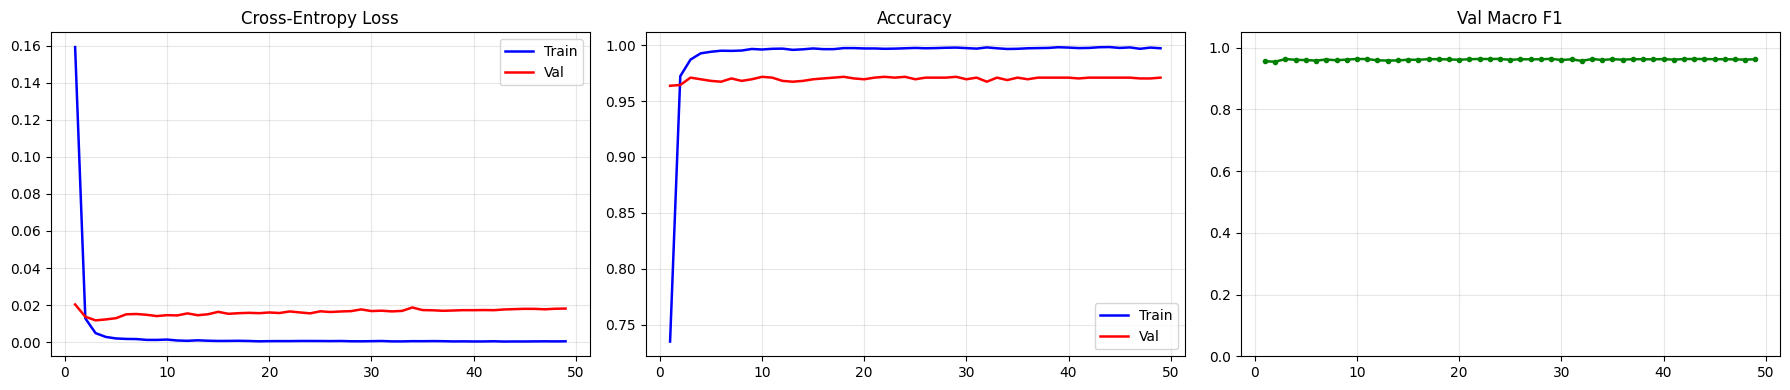

Best val_accuracy : 0.9717


In [17]:
loss     = history_clf.history.get("loss", [])
val_loss = history_clf.history.get("val_loss", [])
acc      = history_clf.history.get("accuracy", [])
val_acc  = history_clf.history.get("val_accuracy", [])
macro_f1 = per_cat_cb.history.get("macro_f1", [])
epochs   = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, loss,     "b-", label="Train", linewidth=1.8)
axes[0].plot(epochs, val_loss, "r-", label="Val",   linewidth=1.8)
axes[0].set_title("Cross-Entropy Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, acc,     "b-", label="Train", linewidth=1.8)
axes[1].plot(epochs, val_acc, "r-", label="Val",   linewidth=1.8)
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

if macro_f1:
    ep2 = range(1, len(macro_f1) + 1)
    axes[2].plot(ep2, macro_f1, "g-o", markersize=3, linewidth=1.8)
    axes[2].set_title("Val Macro F1"); axes[2].set_ylim(0, 1.05); axes[2].grid(alpha=0.3)
    print(f"Best val_macro_f1 : {max(macro_f1):.4f}  (epoch {macro_f1.index(max(macro_f1)) + 1})")

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Best val_accuracy : {max(val_acc):.4f}")


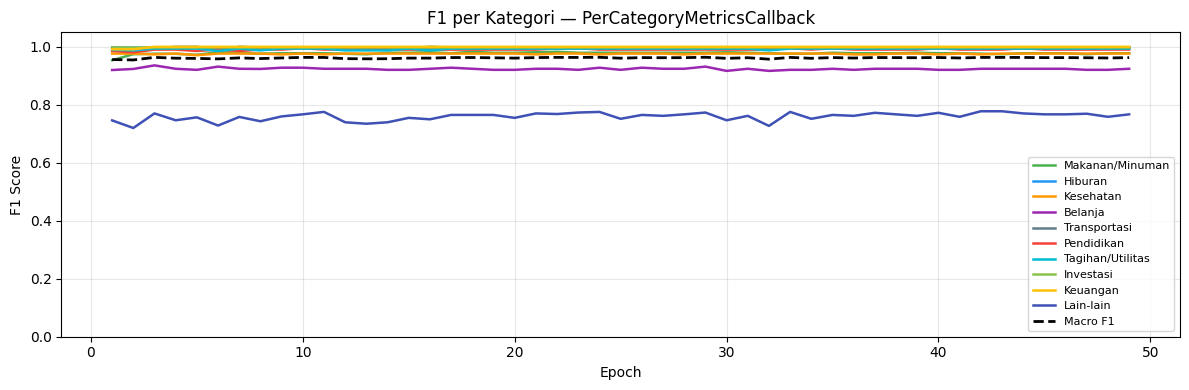

In [18]:
COLORS = ["#4CAF50","#2196F3","#FF9800","#9C27B0","#607D8B",
          "#F44336","#00BCD4","#8BC34A","#FFC107","#3F51B5"]

fig, ax = plt.subplots(figsize=(12, 4))
for cat, color in zip(config.CATEGORIES, COLORS):
    f1_hist = per_cat_cb.history.get(cat, [])
    if f1_hist:
        ax.plot(range(1, len(f1_hist)+1), f1_hist, label=cat, color=color, linewidth=1.8)
if macro_f1:
    ax.plot(range(1, len(macro_f1)+1), macro_f1, "k--", linewidth=2, label="Macro F1")

ax.set_xlabel("Epoch"); ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.05)
ax.set_title("F1 per Kategori — PerCategoryMetricsCallback")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/f1_per_category.png", dpi=120, bbox_inches="tight")
plt.show()


=== Classification Report (Test Set) ===
                  precision    recall  f1-score   support

 Makanan/Minuman       0.96      0.97      0.97       297
         Hiburan       0.98      1.00      0.99        56
       Kesehatan       1.00      0.97      0.99       175
         Belanja       0.98      0.88      0.93       130
    Transportasi       1.00      0.99      1.00       197
      Pendidikan       1.00      0.97      0.99       106
Tagihan/Utilitas       0.99      0.99      0.99       244
       Investasi       1.00      1.00      1.00        49
        Keuangan       1.00      1.00      1.00        58
       Lain-lain       0.70      0.91      0.79        64

        accuracy                           0.97      1376
       macro avg       0.96      0.97      0.96      1376
    weighted avg       0.97      0.97      0.97      1376



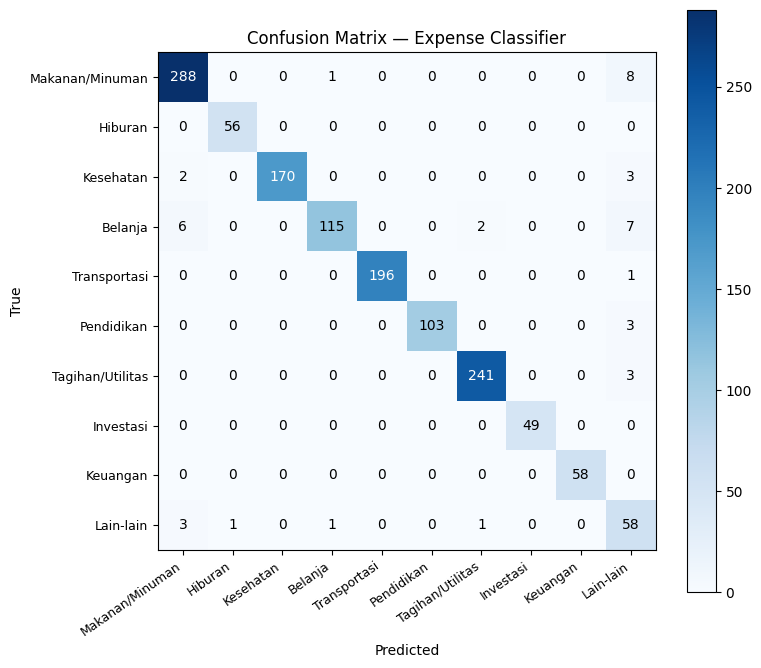

In [19]:
y_true_all, y_pred_all = [], []
for x_batch, y_batch in test_ds:
    probs = clf_model(x_batch, training=False).numpy()
    y_pred_all.append(np.argmax(probs, axis=1))
    y_true_all.append(np.argmax(y_batch.numpy(), axis=1))

y_true = np.concatenate(y_true_all)
y_pred = np.concatenate(y_pred_all)

present_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
present_names  = [config.CATEGORIES[i] for i in present_labels]

print("=== Classification Report (Test Set) ===")
print(classification_report(y_true, y_pred,
                             labels=present_labels,
                             target_names=present_names))

cm  = confusion_matrix(y_true, y_pred, labels=present_labels)
fig, ax = plt.subplots(figsize=(8, 7))
im  = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(present_labels))); ax.set_yticks(range(len(present_labels)))
ax.set_xticklabels(present_names, rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(present_names, fontsize=9)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Expense Classifier")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)
plt.colorbar(im, ax=ax); plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. TensorBoard

```python
%load_ext tensorboard
%tensorboard --logdir /kaggle/working/tensorboard_logs
```

Metrics yang dilog: `loss` · `val_loss` · `accuracy` · `val_accuracy` · `val_macro_f1` · `per_category_f1` · `learning_rate`

In [20]:
try:
    %load_ext tensorboard
    %tensorboard --logdir /kaggle/working/tensorboard_logs
except Exception as e:
    print(f"TensorBoard inline gagal: {e}")
    print(f"Jalankan manual: tensorboard --logdir {config.TB_LOG_DIR}")


<IPython.core.display.Javascript object>

## 7. Export — Production Artifacts


In [21]:
import zipfile, json as _json

Path("/kaggle/working/models").mkdir(parents=True, exist_ok=True)

# Simpan vectorizer vocab
vocab = vectorizer.get_vocabulary()
with open(str(config.VOCAB_PATH), "w", encoding="utf-8") as f:
    _json.dump(vocab, f, ensure_ascii=False)
print(f"Vocab    : {config.VOCAB_PATH}  ({len(vocab)} tokens)")

# Simpan model
clf_model.save(str(config.CLF_MODEL_PATH))
print(f"Classifier: {config.CLF_MODEL_PATH}")
print(f"  Params : {clf_model.count_params():,}")

# Test load
from custom_components import CUSTOM_OBJECTS
clf_reload = tf.keras.models.load_model(
    str(config.CLF_MODEL_PATH), custom_objects=CUSTOM_OBJECTS
)
print(f"Test load → {clf_reload.count_params():,} params — OK")
del clf_reload

# Zip artifacts
ZIP_PATH = "/kaggle/working/hematIn_artifacts.zip"
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for fp in Path("/kaggle/working/models").rglob("*"):
        if fp.is_file():
            zf.write(fp, fp.relative_to("/kaggle/working"))
    for png in Path("/kaggle/working").glob("*.png"):
        zf.write(png, png.name)
print(f"Artifacts : {ZIP_PATH}  ({Path(ZIP_PATH).stat().st_size / 1024**2:.1f} MB)")

# Zip TensorBoard logs
tb_path = Path("/kaggle/working/tensorboard_logs")
if tb_path.exists() and any(tb_path.iterdir()):
    import shutil
    shutil.make_archive("/kaggle/working/tensorboard_logs", "zip", str(tb_path))
    print("TensorBoard logs di-zip ke: /kaggle/working/tensorboard_logs.zip")


Vocab    : /kaggle/working/models/vectorizer_vocab.json  (1109 tokens)
Classifier: /kaggle/working/models/hematin_classifier.keras
  Params : 483,178
Test load → 483,178 params — OK
Artifacts : /kaggle/working/hematIn_artifacts.zip  (3.1 MB)
TensorBoard logs di-zip ke: /kaggle/working/tensorboard_logs.zip


## 8. Inferensi

### 8.1 Load Models

In [22]:
import config, tensorflow as tf
import ocr_pipeline
from pathlib import Path
from custom_components import CUSTOM_OBJECTS

# ── Load Classifier ────────────────────────────────────────────────────────────
clf_path = Path(config.CLF_MODEL_PATH)

if clf_path.exists():
    clf_model = tf.keras.models.load_model(
        str(clf_path), custom_objects=CUSTOM_OBJECTS
    )
    print(f"Classifier : {clf_model.count_params():,} params — OK")
    print(f"Inputs     : {[i.name for i in clf_model.inputs]}")
else:
    print("[WARN] hematin_classifier.keras belum ada — jalankan training dulu")
    clf_model = None

# ── Load ONNX OCR Engine ───────────────────────────────────────────────────────
# Model: hematin_detector.onnx + hematin_recognition.onnx
# Keduanya PP-OCRv5 yang sudah di-fine-tune pada dataset struk Indonesia
try:
    from ocr_pipeline import get_ocr_engine
    ocr_engine = get_ocr_engine()
    print("OCR Engine : ONNXReceiptOCR — OK")
    print(f"Det model  : {ocr_pipeline.DET_MODEL_PATH.name}")
    print(f"Rec model  : {ocr_pipeline.REC_MODEL_PATH.name}")
except FileNotFoundError as e:
    print(f"[WARN] ONNX model tidak ditemukan: {e}")
    ocr_engine = None
except Exception as e:
    print(f"[ERROR] Gagal load OCR engine: {e}")
    ocr_engine = None

import ocr_pipeline

Classifier : 483,178 params — OK
Inputs     : ['text', 'tabular']
OCR Engine : ONNXReceiptOCR — OK
Det model  : hematin_detector.onnx
Rec model  : hematin_recognition.onnx


### 8.2 Demo Classifier — Input Teks Langsung


In [23]:
import importlib, sys, pipeline
importlib.reload(pipeline)
from pipeline import classify_receipt

Teks Input                             Kategori                Conf  Status
--------------------------------------------------------------------------------
  aqua 600ml indomie goreng            Makanan/Minuman        0.974  ✓
  laptop asus vivobook 14              Belanja                0.670  ✓
  tiket bioskop avengers               Hiburan                0.885  ✓
  deterjen rinso 900g                  Belanja                0.695  ✓
  grab motor ojek online               Transportasi           0.960  ✓
  samsung galaxy a55 5g                Belanja                0.613  ✓


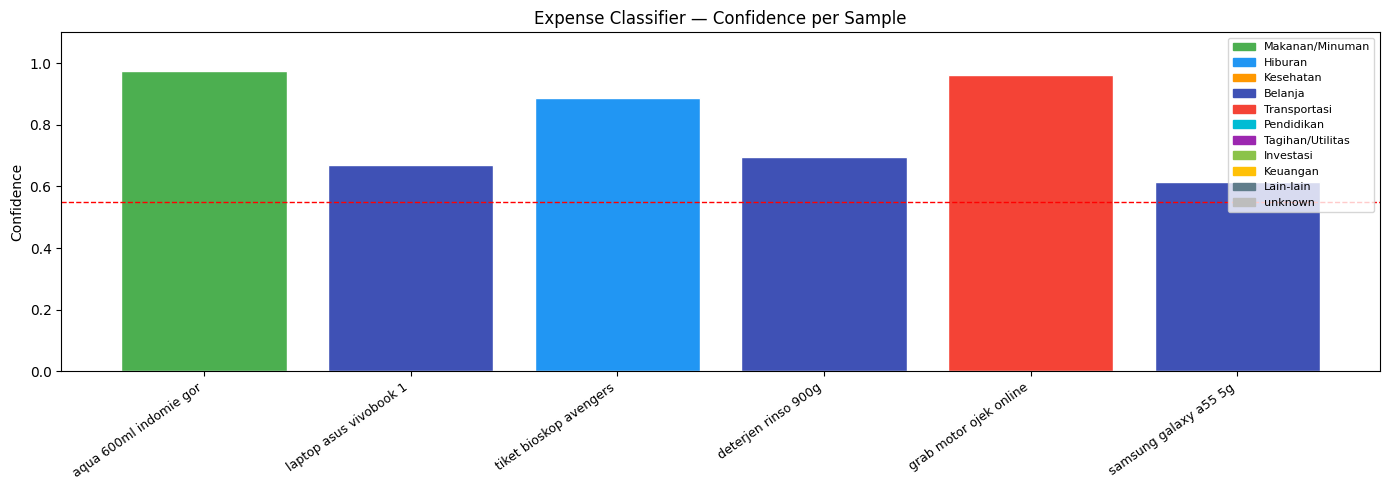

In [24]:
import matplotlib.patches as mpatches
from pipeline import classify_receipt
from config import clean_text, build_tabular_features, CATEGORIES, CONFIDENCE_THRESHOLD

TEST_CASES = [
    ("aqua 600ml indomie goreng",    8_500),
    ("laptop asus vivobook 14",  8_500_000),
    ("tiket bioskop avengers",      75_000),
    ("deterjen rinso 900g",         32_000),
    ("grab motor ojek online",      18_000),
    ("samsung galaxy a55 5g",    5_000_000),
]

CMAP = {
    "Makanan/Minuman" : "#4CAF50", "Hiburan"          : "#2196F3",
    "Kesehatan"       : "#FF9800", "Belanja"          : "#3F51B5",
    "Transportasi"    : "#F44336", "Pendidikan"       : "#00BCD4",
    "Tagihan/Utilitas": "#9C27B0", "Investasi"        : "#8BC34A",
    "Keuangan"        : "#FFC107", "Lain-lain"        : "#607D8B",
    "unknown"         : "#BDBDBD",
}

if clf_model is not None:
    results = []
    print(f"{'Teks Input':<38} {'Kategori':<22} {'Conf':>5}  Status")
    print("-" * 80)
    for text, total in TEST_CASES:
        r = classify_receipt(clean_text(text),
                             build_tabular_features(total).tolist(),
                             clf_model)
        results.append((text, r))
        flag = "✓" if r["is_confident"] else "⚠ low"
        print(f"  {text:<36} {r['category']:<22} {r['confidence']:.3f}  {flag}")

    fig, ax = plt.subplots(figsize=(14, 5))
    confs  = [r[1]["confidence"] for r in results]
    cats   = [r[1]["category"]   for r in results]
    colors = [CMAP.get(c, "#999") for c in cats]
    ax.bar(range(len(results)), confs, color=colors, edgecolor="white")
    ax.axhline(CONFIDENCE_THRESHOLD, color="red", linestyle="--", linewidth=1,
               label=f"threshold={CONFIDENCE_THRESHOLD}")
    ax.set_xticks(range(len(results)))
    ax.set_xticklabels([r[0][:22] for r in results], rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Confidence"); ax.set_ylim(0, 1.1)
    ax.set_title("Expense Classifier — Confidence per Sample")
    legend = [mpatches.Patch(color=v, label=k) for k, v in CMAP.items()]
    ax.legend(handles=legend, loc="upper right", fontsize=8)
    plt.tight_layout(); plt.show()


### 8.3 Demo Full Pipeline — Gambar Struk → Kategori

Menggunakan model ONNX fine-tuned:
- **hematin_detector.onnx** untuk deteksi area teks
- **hematin_recognition.onnx** untuk membaca teks dari setiap crop
- **classifier.keras** untuk mengklasifikasikan pengeluaran

[INFER] Folder : /kaggle/input/datasets/herdinthorikn/capstonedataset/OCR_Inferencev2
[INFER] Gambar : 5 file ditemukan
  - WhatsApp Image 2026-05-28 at 22.06.17.jpeg
  - WhatsApp Image 2026-06-04 at 15.32.15.jpeg
  - WhatsApp Image 2026-06-04 at 15.39.34.jpeg
  - WhatsApp Image 2026-06-04 at 15.42.19.jpeg
  - WhatsApp Image 2026-06-04 at 16.52.45.jpeg

=== WhatsApp Image 2026-05-28 at 22.06.17.jpeg ===
[extract_fields] clf_text  : 'orosutan urj0yogyakarta tbl312 ref b69itvqr tingkatpedas none free teksturmie me'
[extract_fields] total     : 276,003
[extract_fields] tab_feats : [0.27600300312042236, 5.624028205871582, 0.050182364881038666, 0.550000011920929, 0.0, 0.0]
  OCR lines  : 60 baris
  Merchant   : -
  Total      : Rp 276,003
  Items      : 11 jenis
  Kategori   : Lain-lain  (conf=0.900)
  Confident  : ✓
=== WhatsApp Image 2026-06-04 at 15.32.15.jpeg ===
[extract_fields] clf_text  : 'plaicafe hazelnut tunailunas'
[extract_fields] total     : 18,000
[extract_fields] tab_feats : 

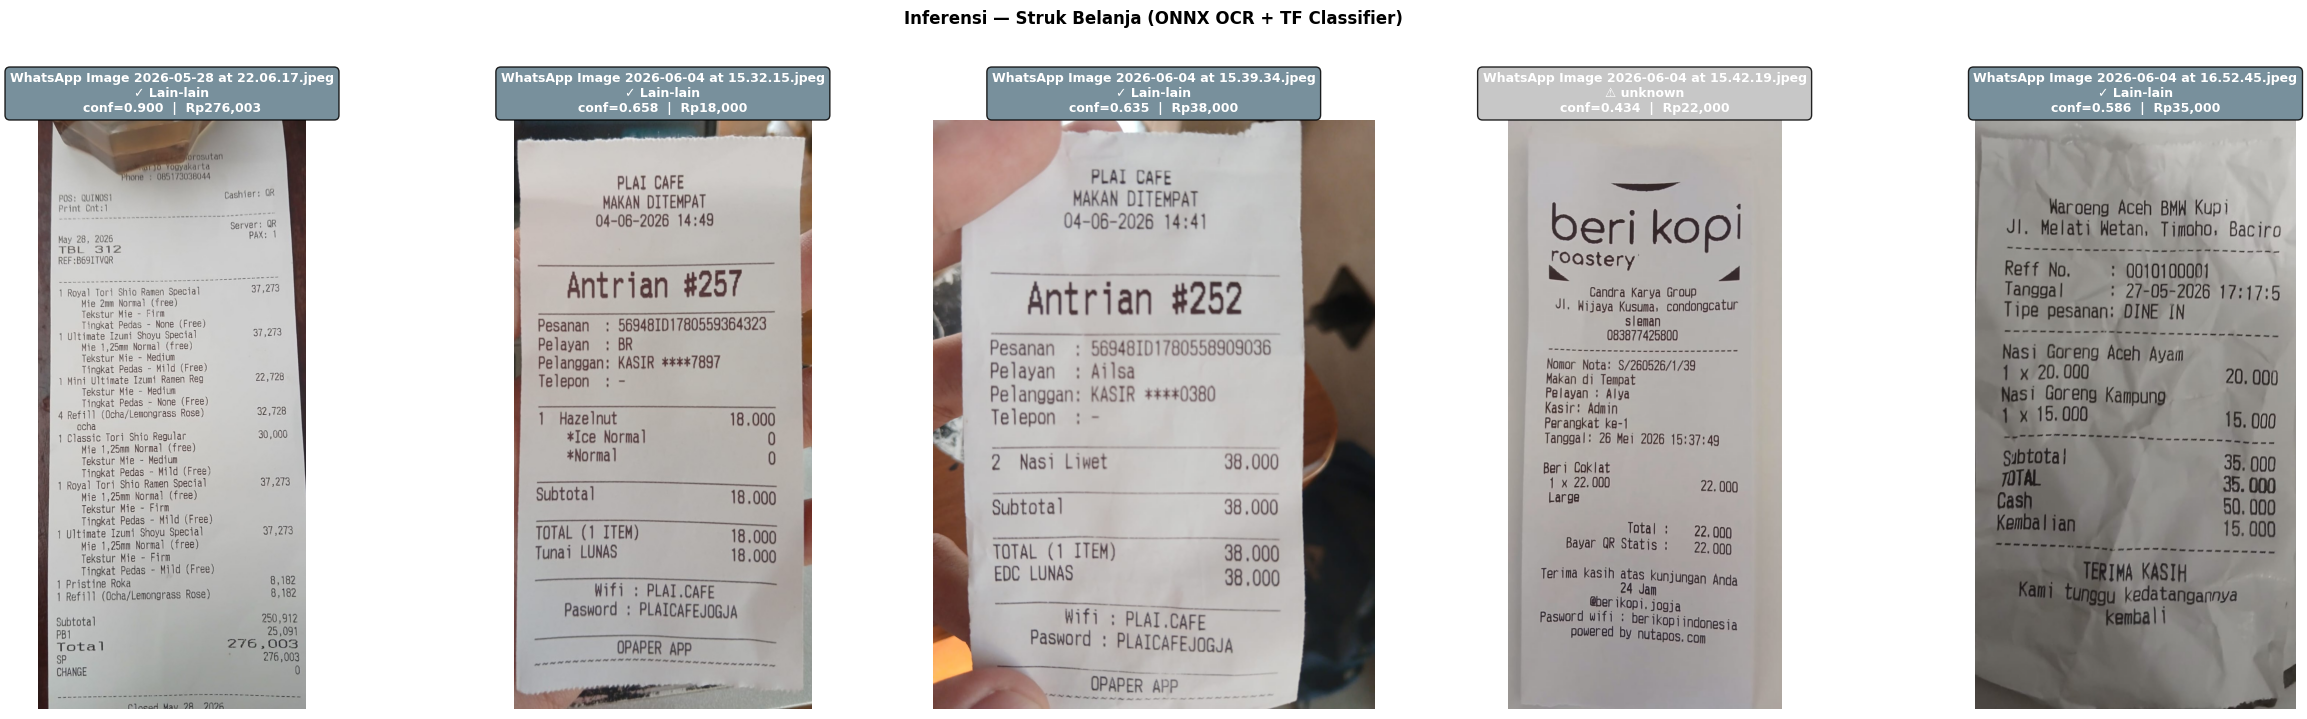


[INFER] Hasil disimpan ke /kaggle/working/inferensi_results.json


In [25]:
import cv2, json
from pathlib import Path
from image_preprocessing import preprocess_image
from ocr_pipeline import run_ocr, ocr_to_lines
from receipt_parser import extract_fields
from pipeline import classify_receipt, analyze_receipt

# ── Konfigurasi path gambar inferensi ─────────────────────────────────────────
INFER_DIR  = config.INFER_DIR
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

infer_images = sorted([
    p for p in INFER_DIR.iterdir()
    if p.suffix.lower() in VALID_EXTS
]) if INFER_DIR.exists() else []

print(f"[INFER] Folder : {INFER_DIR}")
print(f"[INFER] Gambar : {len(infer_images)} file ditemukan")
for p in infer_images:
    print(f"  - {p.name}")

if not infer_images:
    print("\n[WARN] Folder kosong. Upload gambar struk ke INFER_DIR dulu.")
elif clf_model is None:
    print("\n[WARN] hematin_classifier.keras belum di-load. Jalankan Section 8.1 dulu.")
elif ocr_engine is None:
    print("\n[WARN] ONNX model belum tersedia. Pastikan hematin_detector.onnx dan hematin_recognition.onnx ada di INFER_DIR.")
else:
    print()
    results = []
    for img_path in infer_images:
        print(f"=== {img_path.name} ===")
        try:
            result = analyze_receipt(
                img_source   = img_path,
                clf_model    = clf_model,
                deskew       = True,
                min_ocr_conf = 0.3,
            )
            result["source_file"] = img_path.name
            result["status"]      = "ok"
            f = result["fields"]
            c = result["classification"]
            print(f"  OCR lines  : {result['ocr_count']} baris")
            print(f"  Merchant   : {f.get('merchant', '-')}")
            print(f"  Total      : Rp {f.get('total_expense', 0):,.0f}")
            print(f"  Items      : {f.get('distinct_item_count', 0)} jenis")
            print(f"  Kategori   : {c['category']}  (conf={c['confidence']:.3f})")
            print(f"  Confident  : {'✓' if c['is_confident'] else ' below threshold'}")
        except Exception as e:
            print(f"  [ERROR] {e}")
            result = {"source_file": img_path.name, "status": "error", "error": str(e)}
        results.append(result)

    # ── Tabel ringkasan ────────────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print(f"{'File':<28} {'Kategori':<22} {'Conf':>5}  {'Total':>14}")
    print('-'*70)
    for r in results:
        if r["status"] == "ok":
            f, c = r["fields"], r["classification"]
            flag = "✓" if c["is_confident"] else "⚠"
            print(f"  {r['source_file']:<26} {c['category']:<22} {c['confidence']:.3f}  Rp{f['total_expense']:>10,.0f} {flag}")
        else:
            print(f"  {r['source_file']:<26} ERROR: {r.get('error','')[:30]}")

    # ── Visualisasi gambar + label ─────────────────────────────────────────────
    CMAP = {
        "Makanan/Minuman" : "#4CAF50", "Hiburan"          : "#2196F3",
        "Kesehatan"       : "#FF9800", "Belanja"          : "#3F51B5",
        "Transportasi"    : "#F44336", "Pendidikan"       : "#00BCD4",
        "Tagihan/Utilitas": "#9C27B0", "Investasi"        : "#8BC34A",
        "Keuangan"        : "#FFC107", "Lain-lain"        : "#607D8B",
        "unknown"         : "#BDBDBD",
    }
    ok_results = [r for r in results if r["status"] == "ok"]
    if ok_results:
        n   = len(ok_results)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 7))
        if n == 1:
            axes = [axes]
        for ax, r in zip(axes, ok_results):
            img = cv2.imread(str(INFER_DIR / r["source_file"]))
            if img is not None:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            c     = r["classification"]
            f     = r["fields"]
            color = CMAP.get(c["category"], "#999999")
            flag  = "✓" if c["is_confident"] else "⚠"
            ax.set_title(
                f"{r['source_file']}\n{flag} {c['category']}\n"
                f"conf={c['confidence']:.3f}  |  Rp{f['total_expense']:,.0f}",
                fontsize=9, color="white", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.4", facecolor=color, alpha=0.85),
            )
            ax.axis("off")
        plt.suptitle("Inferensi — Struk Belanja (ONNX OCR + TF Classifier)", fontsize=12, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.savefig("/kaggle/working/inferensi_grid.png", dpi=120, bbox_inches="tight")
        plt.show()

    # ── Export JSON ────────────────────────────────────────────────────────────
    out_path = "/kaggle/working/inferensi_results.json"
    with open(out_path, "w", encoding="utf-8") as f_out:
        json.dump(results, f_out, indent=2, ensure_ascii=False, default=str)
    print(f"\n[INFER] Hasil disimpan ke {out_path}")

In [27]:
# Simpan environment
!pip freeze > requirements.txt
